# 🚍 CityFlo Bus Service Metro Cities
## Data Understanding, Data Cleaning and Exploratory Data Analysis using Python

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

# 1. Introduction

Public transportation systems generate large volumes of operational and customer-related data every day. Analyzing this information helps transport operators understand booking behavior, passenger preferences, trip performance, revenue generation, and service quality.

The CityFlo Bus Service Metro Cities dataset contains detailed information about bus bookings, customer demographics, travel characteristics, payment methods, booking channels, operational performance, and customer feedback. These records provide valuable insights into both customer behavior and business operations.

The primary objective of this project is to perform comprehensive data understanding, data cleaning, and exploratory data analysis (EDA) to transform the raw dataset into a high-quality analytical dataset. The preprocessing pipeline is designed to be reusable and robust, enabling it to handle similar datasets with minimal modification.

This notebook follows a systematic workflow consisting of:

- Data Understanding
- Data Cleaning
- Exploratory Data Analysis
- Business Insights

The cleaned dataset obtained through this workflow can be further utilized for visualization, business intelligence, statistical analysis, or predictive machine learning applications.

# 2. Objectives

The objectives of this project are:

- Understand the overall structure and characteristics of the dataset.
- Identify data quality issues such as missing values, duplicates, inconsistent formats, and incorrect data types.
- Build a reusable preprocessing pipeline capable of handling similar transportation datasets.
- Standardize and clean the dataset to improve reliability.
- Explore customer booking behavior and operational trends.
- Generate meaningful business insights through exploratory data analysis.
- Prepare a clean dataset suitable for further predictive analytics and machine learning.

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 150)
print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Dataset Loading

The dataset is imported into a Pandas DataFrame for analysis. Once loaded, the first few records are displayed to verify that the dataset has been imported correctly and to obtain an initial understanding of its structure.

In [91]:
df = pd.read_csv("/kaggle/input/datasets/rishijmanna/cityflo-bus-service-metro-cities-cleaned/cityflo_bus_service_metro_cities_cleaned.csv")
df.head()

,trip_id,booking_id,customer_id,customer_name,gender,age,city,route_id,route_name,origin_stop,destination_stop,bus_number,bus_type,driver_id,driver_name,trip_date,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,distance_km,fare_inr,discount_inr,payment_mode,booking_channel,seat_number,trip_status,cancellation_reason,rating,occupancy_pct,weather,is_peak_hour,subscription_type,device_type,gps_enabled,complaint_raised
0,Trp000768,Bk47984879,Cust01278,Shalini Verma,Female,21.0,Mumbai,Rtmu005,Lower Parel - Mulund,Lower Parel,Mulund,Mh23Cf4441,Ac Sleeper,Drv0080,Aarav Bhat,2024-09-21,2026-07-30 20:25:00,20:25,2026-07-30 20:58:00,20:58,10.9,153,0.0,Upi,Corporate Portal,D8,Completed,Nan,5.0,84.6,Haze,0,Corporate Plan,Ios,True,No
1,Trp002439,Bk14257322,Cust01290,Kalpana Chopra,Male,24.0,Hyderabad,Rthy038,Hitec City - Kondapur,Hitec City,Kondapur,Ts27Cf8651,Ac Seater,Drv0068,Sanjay Joshi,2024-08-08,2026-07-30 14:50:00,15:12,2026-07-30 15:29:00,15:51,14.1,127,0.0,Debit Card,Kiosk,D7,Delayed-Completed,Nan,4.0,28.3,Heavy Rain,False,Weekly Pass,Android,True,0
2,Trp000793,Bk67236768,Cust01285,Sai Naidu,Female,18.0,Pune,Rtpu012,Aundh - Magarpatta,Aundh,Magarpatta,Mh24Cf3646,Ac Seater,Drv0001,Lakshmi Patel,2024-03-19,2026-07-30 08:15:00,08:15,2026-07-30 09:42:00,09:42,27.6,234,19.0,Cash,Corporate Portal,D11,Completed,Nan,3.0,15.4,Cloudy,1,Single Ride,Android,Yes,No
3,Trp002802,Bk59659578,Cust00625,Priya Patel,Female,23.0,Mumbai,Rtmu010,Ghatkopar - Lower Parel,Ghatkopar,Lower Parel,Mh13Cf5853,Ac Sleeper,Drv0036,Siddharth Kumar,2024-12-29,2026-07-30 17:45:00,17:45,2026-07-30 18:57:00,Nan,28.6,310,0.0,Debit Card,Corporate Portal,D11,No-Show,Customer Request,4.0,68.1,Clear,No,Corporate Plan,Web,1,Yes
4,Trp001653,Bk19231279,Cust00276,Shalini Kulkarni,F,20.0,Bangalore,Rtba024,Hebbal - Electronic City,Hebbal,Electronic City,Ka22Cf6238,Ac Seater,Drv0045,Sunita Gupta,2024-05-15,2026-07-30 13:00:00,13:40,2026-07-30 13:35:00,14:15,17.8,202,0.0,Upi,Corporate Portal,A1,Delayed-Completed,Nan,4.0,23.7,Haze,No,Corporate Plan,Ios,True,0


# 4. Dataset Overview

Understanding the overall characteristics of a dataset is the first step before performing preprocessing or analysis. This section summarizes the dataset size, structure, memory usage, and overall completeness.

In [92]:
print("CITYFLO DATASET OVERVIEW")

print(f"Number of Observations : {df.shape[0]:,}")
print(f"Number of Features     : {df.shape[1]}")

print(f"\nMemory Usage : {df.memory_usage(deep=True).sum()/(1024**2):.2f} MB")

print(f"\nDuplicate Rows : {df.duplicated().sum()}")

print(f"Missing Values : {df.isnull().sum().sum()}")

print(f"Total Cells : {df.size:,}")

print(f"Missing Percentage : {(df.isnull().sum().sum()/df.size)*100:.2f}%")

CITYFLO DATASET OVERVIEW
Number of Observations : 3,200
Number of Features     : 36

Memory Usage : 5.55 MB

Duplicate Rows : 0
Missing Values : 0
Total Cells : 115,200
Missing Percentage : 0.00%


# Dataset Snapshot

The following sample records provide an overview of the information contained in the dataset. Reviewing representative observations helps verify successful data loading and offers an initial understanding of the available features.

In [93]:
display(df.head(10))

,trip_id,booking_id,customer_id,customer_name,gender,age,city,route_id,route_name,origin_stop,destination_stop,bus_number,bus_type,driver_id,driver_name,trip_date,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,distance_km,fare_inr,discount_inr,payment_mode,booking_channel,seat_number,trip_status,cancellation_reason,rating,occupancy_pct,weather,is_peak_hour,subscription_type,device_type,gps_enabled,complaint_raised
0,Trp000768,Bk47984879,Cust01278,Shalini Verma,Female,21.0,Mumbai,Rtmu005,Lower Parel - Mulund,Lower Parel,Mulund,Mh23Cf4441,Ac Sleeper,Drv0080,Aarav Bhat,2024-09-21,2026-07-30 20:25:00,20:25,2026-07-30 20:58:00,20:58,10.9,153,0.0,Upi,Corporate Portal,D8,Completed,Nan,5.0,84.6,Haze,0,Corporate Plan,Ios,True,No
1,Trp002439,Bk14257322,Cust01290,Kalpana Chopra,Male,24.0,Hyderabad,Rthy038,Hitec City - Kondapur,Hitec City,Kondapur,Ts27Cf8651,Ac Seater,Drv0068,Sanjay Joshi,2024-08-08,2026-07-30 14:50:00,15:12,2026-07-30 15:29:00,15:51,14.1,127,0.0,Debit Card,Kiosk,D7,Delayed-Completed,Nan,4.0,28.3,Heavy Rain,False,Weekly Pass,Android,True,0
2,Trp000793,Bk67236768,Cust01285,Sai Naidu,Female,18.0,Pune,Rtpu012,Aundh - Magarpatta,Aundh,Magarpatta,Mh24Cf3646,Ac Seater,Drv0001,Lakshmi Patel,2024-03-19,2026-07-30 08:15:00,08:15,2026-07-30 09:42:00,09:42,27.6,234,19.0,Cash,Corporate Portal,D11,Completed,Nan,3.0,15.4,Cloudy,1,Single Ride,Android,Yes,No
3,Trp002802,Bk59659578,Cust00625,Priya Patel,Female,23.0,Mumbai,Rtmu010,Ghatkopar - Lower Parel,Ghatkopar,Lower Parel,Mh13Cf5853,Ac Sleeper,Drv0036,Siddharth Kumar,2024-12-29,2026-07-30 17:45:00,17:45,2026-07-30 18:57:00,Nan,28.6,310,0.0,Debit Card,Corporate Portal,D11,No-Show,Customer Request,4.0,68.1,Clear,No,Corporate Plan,Web,1,Yes
4,Trp001653,Bk19231279,Cust00276,Shalini Kulkarni,F,20.0,Bangalore,Rtba024,Hebbal - Electronic City,Hebbal,Electronic City,Ka22Cf6238,Ac Seater,Drv0045,Sunita Gupta,2024-05-15,2026-07-30 13:00:00,13:40,2026-07-30 13:35:00,14:15,17.8,202,0.0,Upi,Corporate Portal,A1,Delayed-Completed,Nan,4.0,23.7,Haze,No,Corporate Plan,Ios,True,0
5,Trp003149,Bk80329799,Cust01233,Ramesh Iyer,Male,35.0,Mumbai,Rtmu008,Thane West - Mulund,Thane West,Mulund,Mh31Cf4644,Ac Sleeper,Drv0047,Rohan Bansal,2024-11-11,2026-07-30 08:40:00,08:35,2026-07-30 09:42:00,09:37,23.5,292,56.0,Upi,Website,A2,Completed,Nan,5.0,42.5,Clear,True,Single Ride,Web,Y,No
6,Trp002453,Bk45540207,Cust00862,Sunita Joshi,Female,35.0,Delhi Ncr,Rtde055,Vasant Kunj - Connaught Place,Vasant Kunj,Connaught Place,Dl13Cf2245,Ac Sleeper,Drv0055,Aditya Mehta,01/03/2024,2026-07-30 09:20:00,09:25,2026-07-30 09:42:00,09:47,8.4,98,0.0,Cash,Mobile App,A6,Completed,Nan,2.0,67.7,Haze,1,Single Ride,Ios,True,0
7,Trp003148,Bk94474114,Cust00421,Krishna Joshi,F,40.0,Mumbai,Rtmu001,Ghatkopar - Vashi,Ghatkopar,Vashi,Mh49Cf4872,Ac Sleeper,Drv0034,Shalini Gupta,2024-03-26,2026-07-30 19:40:00,19:40,2026-07-30 21:21:00,21:21,32.5,471,0.0,Debit Card,Corporate Portal,C4,Completed,Nan,4.0,83.3,Haze,True,Single Ride,Ios,No,0
8,Trp000788,Bk34814909,Cust01204,Saanvi Gupta,Male,46.0,Bangalore,Rtba022,Hsr Layout - Bannerghatta Road,Hsr Layout,Bannerghatta Road,Ka22Cf6238,Ac Seater,Drv0062,Tanvi Reddy,2024-11-20,2026-07-30 20:50:00,20:50,2026-07-30 22:53:00,Nan,40.7,343,0.0,Upi,Website,C11,No-Show,Customer Request,4.0,23.4,Rain,1,Weekly Pass,Web,True,No
9,Trp001583,Bk20246842,Cust00520,Myra Pillai,Male,37.0,Delhi Ncr,Rtde051,Vasant Kunj - Saket,Vasant Kunj,Saket,Dl07Cf6794,Premium Ac,Drv0027,Aditya Naidu,2024-09-29,2026-07-30 12:15:00,12:15,2026-07-30 13:17:00,13:17,25.7,361,0.0,Cash,Corporate Portal,D15,Completed,Nan,4.0,88.6,Cloudy,0,Single Ride,Ios,True,No


# Random Sample of Records

Displaying randomly selected observations provides a more representative view of the dataset and helps identify potential inconsistencies that may not appear in the first few records.

In [94]:
display(df.sample(10, random_state=42))

,trip_id,booking_id,customer_id,customer_name,gender,age,city,route_id,route_name,origin_stop,destination_stop,bus_number,bus_type,driver_id,driver_name,trip_date,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,distance_km,fare_inr,discount_inr,payment_mode,booking_channel,seat_number,trip_status,cancellation_reason,rating,occupancy_pct,weather,is_peak_hour,subscription_type,device_type,gps_enabled,complaint_raised
2384,Trp003013,Bk36795085,Cust00180,Manoj Chopra,M,20.0,Chennai,Rtch041,Adyar - Guindy,Adyar,Guindy,Tn29Cf2982,Ac Sleeper,Drv0086,Rohan Pillai,08/01/2024,2026-07-30 20:40:00,Nan,2026-07-30 21:14:00,Nan,18.2,Inr 0,0.0,Nan,Website,D12,Cancelled,Driver Unavailable,4.0,58.5,Fog,True,Monthly Pass,Web,Y,No
2538,Trp002913,Bk29086250,Cust00915,Deepak Iyer,Female,30.0,Delhi Ncr,Rtde055,Vasant Kunj - Connaught Place,Vasant Kunj,Connaught Place,Dl20Cf9317,Ac Sleeper,Drv0087,Aarav Naidu,2024-02-11,2026-07-30 15:10:00,15:10,2026-07-30 15:35:00,15:35,8.4,89,10.0,Credit Card,Website,D6,Completed,Nan,4.0,74.5,Haze,False,Corporate Plan,Web,Y,No
2176,Trp000930,Bk23108919,Cust00038,Kavya Chopra,Female,30.0,Delhi Ncr,Rtde053,Indirapuram - Rohini,Indirapuram,Rohini,Dl36Cf6419,Non-Ac Seater,Drv0075,Sneha Malhotra,13-Mar-2024,2026-07-30 19:15:00,Nan,2026-07-30 21:17:00,Nan,41.8,0,0.0,Nan,Website,C7,Cancelled,Payment Failed,4.0,58.5,Cloudy,Yes,Weekly Pass,Android,False,0
897,Trp001007,Bk49048137,Cust00032,Geeta Patel,Male,30.0,Bangalore,Rtba021,Bannerghatta Road - Marathahalli,Bannerghatta Road,Marathahalli,Ka42Cf9346,Premium Ac,Drv0016,Pooja Rao,2024-09-25,2026-07-30 20:00:00,20:23,2026-07-30 20:44:00,21:07,22.3,307,0.0,Wallet,Website,B9,Delayed-Completed,Nan,4.0,21.8,Clear,Yes,Corporate Plan,Web,Yes,0
214,Trp001843,Bk80756306,Cust00763,Vihaan Agarwal,Female,22.0,Mumbai,Rtmu007,Thane West - Borivali,Thane West,Borivali,Mh16Cf7658,Premium Ac,Drv0034,Shalini Gupta,06/09/2024,2026-07-30 18:40:00,19:23,2026-07-30 19:23:00,20:06,22.1,270,0.0,Debit Card,Website,D6,Delayed-Completed,Nan,4.0,54.0,Clear,1,Weekly Pass,Web,Y,0
2380,Trp002897,Bk21983915,Cust00624,Anika Verma,Male,19.0,Hyderabad,Rthy031,Kukatpally - Gachibowli,Kukatpally,Gachibowli,Ts08Cf5033,Ac Seater,Drv0047,Rohan Bansal,2024-03-21,2026-07-30 20:05:00,20:05,2026-07-30 21:21:00,Nan,38.9,449,0.0,Cash,Website,C3,No-Show,Customer Request,4.0,73.9,Fog,1,Single Ride,Android,True,0
2714,Trp001962,Bk96629715,Cust01066,Rahul Kapoor,Male,38.0,Chennai,Rtch049,Velachery - Tambaram,Velachery,Tambaram,Tn14Cf9288,Non-Ac Seater,Drv0007,Ramesh Gupta,2024-03-17,2026-07-30 20:55:00,20:55,2026-07-30 22:07:00,22:07,37.6,311,92.0,Net Banking,Corporate Portal,C15,Completed,Nan,4.0,41.4,Rain,No,Single Ride,Ios,Yes,0
2576,Trp001524,Bk46289261,Cust00527,Lakshmi Bhat,Male,25.0,Mumbai,Rtmu006,Malad West - Lower Parel,Malad West,Lower Parel,Mh45Cf5941,Ac Seater,Drv0061,Neha Chopra,2024-12-23,2026-07-30 19:00:00,19:00,2026-07-30 20:23:00,20:23,29.8,380,54.0,Debit Card,Kiosk,C15,Completed,Nan,2.0,74.5,Rain,Yes,Weekly Pass,Android,True,0
102,Trp002093,Bk64899800,Cust00125,Saanvi Pillai,Female,39.0,Bangalore,Rtba027,Yelahanka - Bannerghatta Road,Yelahanka,Bannerghatta Road,Ka15Cf2124,Ac Seater,Drv0077,Isha Malhotra,26-Feb-2024,2026-07-30 20:55:00,20:54,2026-07-30 22:38:00,22:37,33.5,450,123.0,Cash,Kiosk,C5,Completed,Nan,4.0,22.4,Fog,True,Monthly Pass,Ios,False,0
192,Trp000605,Bk34117962,Cust00210,Kalpana Malhotra,M,25.0,Chennai,Rtch048,Guindy - Adyar,Guindy,Adyar,Tn01Cf5978,Non-Ac Seater,Drv0058,Manoj Kulkarni,2024-04-04,2026-07-30 17:20:00,18:10,2026-07-30 17:59:00,18:49,12.9,109,20.0,Wallet,Website,D2,Delayed-Completed,Nan,5.0,90.0,Cloudy,Yes,Corporate Plan,Ios,True,0


# Dataset Dimensions

The dimensions of a dataset indicate the number of observations (rows) and features (columns). Understanding the dataset size helps estimate computational requirements and provides context for subsequent preprocessing and analysis.

In [95]:
rows, columns = df.shape

dimension_summary = pd.DataFrame({
    "Property": [
        "Number of Rows",
        "Number of Columns"
    ],
    "Value": [
        rows,
        columns
    ]
})

display(dimension_summary)

,Property,Value
0,Number of Rows,3200
1,Number of Columns,36


# 5. Data Understanding

## 5.1 Dataset Information

Before performing any preprocessing, it is important to understand the structure of the dataset. This section provides detailed information about each feature, including its data type, number of non-null observations, and memory usage.

Understanding the dataset structure helps identify potential preprocessing requirements such as missing values, incorrect data types, and memory optimization opportunities.

In [96]:
print("DATASET INFORMATION")
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trip_id              3200 non-null   object 
 1   booking_id           3200 non-null   object 
 2   customer_id          3200 non-null   object 
 3   customer_name        3200 non-null   object 
 4   gender               3200 non-null   object 
 5   age                  3200 non-null   float64
 6   city                 3200 non-null   object 
 7   route_id             3200 non-null   object 
 8   route_name           3200 non-null   object 
 9   origin_stop          3200 non-null   object 
 10  destination_stop     3200 non-null   object 
 11  bus_number           3200 non-null   object 
 12  bus_type             3200 non-null   object 
 13  driver_id            3200 non-null   object 
 14  driver_name          3200 non-null   object 
 15  trip_date         

## 5.2 Memory Usage Analysis

Memory optimization is an important aspect of data preprocessing, particularly when working with large datasets. This section reports the memory consumed by each feature as well as the total memory occupied by the dataset.

Understanding memory utilization helps identify opportunities for data type optimization during the cleaning stage.

In [97]:
memory_df = pd.DataFrame({

    "Column": df.columns,

    "Memory (KB)": (
        df.memory_usage(deep=True)[1:] / 1024
    ).round(2)

})

display(memory_df.sort_values(
    "Memory (KB)",
    ascending=False
))

,Column,Memory (KB)
route_name,route_name,218.47
scheduled_arrival,scheduled_arrival,212.50
scheduled_departure,scheduled_departure,212.50
subscription_type,subscription_type,190.70
customer_name,customer_name,189.69
driver_name,driver_name,189.31
bus_type,bus_type,186.03
trip_date,trip_date,185.93
booking_id,booking_id,184.38
bus_number,bus_number,184.38


## 5.3 Feature Metadata

A metadata summary provides a comprehensive overview of every feature within the dataset. It includes information about data types, missing values, unique observations, and representative sample values.

This information serves as the foundation for identifying preprocessing requirements and understanding the nature of each feature.

In [98]:
metadata = pd.DataFrame({

    "Feature": df.columns,

    "Data Type": df.dtypes.astype(str).values,

    "Non-Null": df.count().values,

    "Missing": df.isnull().sum().values,

    "Missing (%)": (
        df.isnull().mean()*100
    ).round(2).values,

    "Unique Values": df.nunique().values,

    "Sample Values":[

        ", ".join(
            map(str,
                df[col].dropna().unique()[:3]
            )
        )

        for col in df.columns

    ]

})

display(metadata)

,Feature,Data Type,Non-Null,Missing,Missing (%),Unique Values,Sample Values
0,trip_id,object,3200,0,0.0,3200,"Trp000768, Trp002439, Trp000793"
1,booking_id,object,3200,0,0.0,3200,"Bk47984879, Bk14257322, Bk67236768"
2,customer_id,object,3200,0,0.0,1251,"Cust01278, Cust01290, Cust01285"
3,customer_name,object,3200,0,0.0,761,"Shalini Verma, Kalpana Chopra, Sai Naidu"
4,gender,object,3200,0,0.0,6,"Female, Male, F"
5,age,float64,3200,0,0.0,40,"21.0, 24.0, 18.0"
6,city,object,3200,0,0.0,6,"Mumbai, Hyderabad, Pune"
7,route_id,object,3200,0,0.0,60,"Rtmu005, Rthy038, Rtpu012"
8,route_name,object,3200,0,0.0,60,"Lower Parel - Mulund, Hitec City - Kondapur, Aundh - Magarpatta"
9,origin_stop,object,3200,0,0.0,40,"Lower Parel, Hitec City, Aundh"


## 5.4 Automatic Feature Classification

Each feature serves a different analytical purpose. Automatically classifying features improves preprocessing decisions and helps determine appropriate analytical techniques.

The features are categorized into:

- Identifier Features
- Numerical Features
- Categorical Features
- Date/Time Features
- Boolean Features

In [99]:
feature_type = []

for col in df.columns:

    if df[col].nunique() == len(df):

        category = "Identifier"

    elif pd.api.types.is_numeric_dtype(df[col]):

        category = "Numerical"

    elif pd.api.types.is_datetime64_any_dtype(df[col]):

        category = "Datetime"

    elif df[col].dropna().isin([True,False]).all():

        category = "Boolean"

    else:

        category = "Categorical"

    feature_type.append(category)

feature_summary = pd.DataFrame({

    "Feature": df.columns,

    "Category": feature_type,

    "Data Type": df.dtypes.astype(str)

})

display(feature_summary)

,Feature,Category,Data Type
trip_id,trip_id,Identifier,object
booking_id,booking_id,Identifier,object
customer_id,customer_id,Categorical,object
customer_name,customer_name,Categorical,object
gender,gender,Categorical,object
age,age,Numerical,float64
city,city,Categorical,object
route_id,route_id,Categorical,object
route_name,route_name,Categorical,object
origin_stop,origin_stop,Categorical,object


## 5.5 Feature Distribution Summary

This section summarizes the distribution of feature types within the dataset. Understanding the composition of the dataset provides an overview of the variables available for analysis and guides subsequent preprocessing decisions.

In [100]:
feature_summary["Category"].value_counts().to_frame(
    "Number of Features"
)

,Number of Features
Category,
Categorical,29
Numerical,5
Identifier,2


## 5.6 Statistical Summary of Numerical Features

Descriptive statistics provide a concise summary of the central tendency, variability, and overall distribution of numerical variables.

The following statistics are reported:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

These measures assist in detecting anomalies, extreme values, and potential preprocessing requirements.

In [101]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,3200.0,29.502813,8.179144,-5.0,24.000,29.0,35.0,130.0
distance_km,3200.0,24.738375,10.291220,8.3,16.000,25.7,33.1,41.8
discount_inr,3200.0,13.536875,30.350303,0.0,0.000,0.0,0.0,203.0
rating,3200.0,3.866250,0.955194,1.0,4.000,4.0,4.0,5.0
occupancy_pct,3200.0,58.334031,23.576593,15.1,39.175,58.5,77.3,138.8


## 5.7 Statistical Summary of Categorical Features

Categorical variables are summarized to identify their frequency distributions, dominant categories, and diversity.

Understanding categorical features assists in detecting inconsistent labels, uncommon categories, and potential standardization requirements.

In [102]:
display(
    df.describe(include="object").T
)

,count,unique,top,freq
trip_id,3200,3200,Trp000722,1
booking_id,3200,3200,Bk82178869,1
customer_id,3200,1251,Cust00449,9
customer_name,3200,761,Isha Shah,22
gender,3200,6,Female,1219
city,3200,6,Mumbai,553
route_id,3200,60,Rtch050,69
route_name,3200,60,Tambaram - Adyar,69
origin_stop,3200,40,Thane West,223
destination_stop,3200,38,Magarpatta,167


## 5.8 Unique Value Summary

The number of distinct values contained within each feature provides insight into its characteristics. Features containing a single unique value may contribute little analytical information, whereas features with very large numbers of unique values often represent identifiers or free-text attributes.

This summary helps identify features requiring further preprocessing.

In [103]:
unique_summary = pd.DataFrame({

    "Feature": df.columns,

    "Unique Values":[

        df[col].nunique()

        for col in df.columns

    ]

})

display(
    unique_summary.sort_values(
        "Unique Values",
        ascending=False
    )
)

,Feature,Unique Values
0,trip_id,3200
1,booking_id,3200
2,customer_id,1251
15,trip_date,1113
18,scheduled_arrival,956
19,actual_arrival,916
29,occupancy_pct,838
17,actual_departure,769
3,customer_name,761
21,fare_inr,729


## 5.9 Initial Data Quality Report

Before applying any preprocessing techniques, an initial quality assessment is performed to evaluate the completeness and integrity of the dataset.

The report summarizes:

- Dataset dimensions
- Missing values
- Duplicate observations
- Feature composition
- Memory usage

This baseline assessment provides a reference for measuring the effectiveness of subsequent data cleaning operations.

In [104]:
quality_report = pd.DataFrame({

    "Metric":[

        "Rows",

        "Columns",

        "Duplicate Rows",

        "Missing Cells",

        "Memory Usage (MB)",

        "Numerical Features",

        "Categorical Features"

    ],

    "Value":[

        len(df),

        len(df.columns),

        df.duplicated().sum(),

        df.isnull().sum().sum(),

        round(
            df.memory_usage(deep=True).sum()/(1024**2),
            2
        ),

        len(
            df.select_dtypes(
                include=np.number
            ).columns
        ),

        len(
            df.select_dtypes(
                include="object"
            ).columns
        )

    ]

})

display(quality_report)

,Metric,Value
0,Rows,3200.00
1,Columns,36.00
2,Duplicate Rows,0.00
3,Missing Cells,0.00
4,Memory Usage (MB),5.55
5,Numerical Features,5.00
6,Categorical Features,31.00


# 6. Data Quality Assessment

## 6.1 Missing Value Analysis

Missing values are one of the most common data quality issues in real-world datasets. They may occur due to incomplete data collection, system failures, manual entry errors, or unavailable information.

This section examines the extent of missing data in each feature by reporting both the number and percentage of missing values. Understanding missing data patterns helps determine appropriate preprocessing strategies during the data cleaning phase.

In [105]:
missing_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing (%)": (
        df.isnull().mean() * 100
    ).round(2).values
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Feature,Missing Values,Missing (%)
0,trip_id,0,0.0
1,booking_id,0,0.0
2,customer_id,0,0.0
3,customer_name,0,0.0
4,gender,0,0.0
5,age,0,0.0
6,city,0,0.0
7,route_id,0,0.0
8,route_name,0,0.0
9,origin_stop,0,0.0


In [106]:
missing_only = missing_summary[
    missing_summary["Missing Values"] > 0
]

if missing_only.empty:
    print("✅ No missing values detected.")
else:
    display(missing_only)

✅ No missing values detected.


## 6.2 Duplicate Record Analysis

Duplicate records may arise due to repeated data collection, synchronization issues, or manual entry errors.

Duplicate observations can distort statistical summaries, introduce bias into analytical models, and increase storage requirements. Therefore, identifying duplicate records is an essential step before performing any preprocessing operations.

In [107]:
duplicate_rows = df.duplicated().sum()

duplicate_percentage = (
    duplicate_rows / len(df)
) * 100

duplicate_report = pd.DataFrame({

    "Metric": [

        "Duplicate Rows",

        "Duplicate Percentage (%)"

    ],

    "Value": [

        duplicate_rows,

        round(duplicate_percentage,2)

    ]

})

display(duplicate_report)

,Metric,Value
0,Duplicate Rows,0.0
1,Duplicate Percentage (%),0.0


In [108]:
if duplicate_rows > 0:

    display(df[df.duplicated()].head())

else:

    print("✅ No duplicate rows found.")

✅ No duplicate rows found.


## 6.3 Duplicate Feature Detection

Occasionally, datasets may contain multiple columns storing identical information under different names. Such duplicate features increase memory usage and may negatively affect analysis.

This section checks whether any pair of features contains exactly the same values throughout the dataset.

In [109]:
duplicate_columns = []

columns = df.columns

for i in range(len(columns)):

    for j in range(i+1, len(columns)):

        if df[columns[i]].equals(df[columns[j]]):

            duplicate_columns.append(
                (columns[i], columns[j])
            )

if duplicate_columns:

    display(pd.DataFrame(
        duplicate_columns,
        columns=[
            "Feature 1",
            "Feature 2"
        ]
    ))

else:

    print("✅ No duplicate columns detected.")

✅ No duplicate columns detected.


## 6.4 Constant Feature Detection

Constant features contain only a single unique value throughout the dataset. Since these variables exhibit no variation, they provide little or no analytical value and are typically removed during preprocessing.

In [110]:
constant_columns = []

for col in df.columns:

    if df[col].nunique(dropna=False) == 1:

        constant_columns.append(col)

constant_df = pd.DataFrame({

    "Constant Features": constant_columns

})

display(constant_df)

,Constant Features


## 6.5 Quasi-Constant Feature Detection

A quasi-constant feature contains one dominant value appearing in the vast majority of observations. Although not completely constant, such variables often contribute very little useful information.

This section identifies features where a single value accounts for more than 95% of all observations.

In [111]:
threshold = 0.95

quasi_constant = []

for col in df.columns:

    dominant_ratio = (
        df[col]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .max()
    )

    if dominant_ratio >= threshold:

        quasi_constant.append({

            "Feature": col,

            "Dominant Ratio": round(
                dominant_ratio,
                4
            )

        })

display(pd.DataFrame(quasi_constant))

""


## 6.6 High Cardinality Detection

Categorical variables containing a very large number of unique categories are referred to as high-cardinality features.

Such variables often represent identifiers, names, or free-text fields. Detecting these features early assists in selecting suitable encoding techniques during later stages of analysis.

high_cardinality = []

for col in df.select_dtypes(include="object"):

    unique = df[col].nunique()

    if unique > 50:

        high_cardinality.append({

            "Feature": col,

            "Unique Values": unique,

            "Unique Ratio (%)": round(
                unique/len(df)*100,
                2
            )

        })

display(
    pd.DataFrame(high_cardinality)
)

## 6.7 Identifier Feature Detection

Identifier features uniquely distinguish individual records rather than describing their characteristics. Examples include booking IDs, customer IDs, transaction IDs, and ticket numbers.

Such features are generally retained for reference but excluded from statistical analysis and predictive modeling.

In [112]:
identifier_columns = []

for col in df.columns:

    if df[col].nunique() == len(df):

        identifier_columns.append(col)

identifier_df = pd.DataFrame({

    "Identifier Features": identifier_columns

})

display(identifier_df)

,Identifier Features
0,trip_id
1,booking_id


## 6.8 Leading and Trailing Whitespace Detection

Leading and trailing spaces are common data entry issues that can cause identical values to be treated as different categories.

This section identifies text features containing unnecessary whitespace so they can be standardized during the cleaning phase.

In [113]:
whitespace_columns = []

for col in df.select_dtypes(include="object").columns:

    if df[col].dropna().astype(str).str.strip().ne(
        df[col].dropna().astype(str)
    ).any():

        whitespace_columns.append(col)

if whitespace_columns:

    display(pd.DataFrame({
        "Features with Extra Spaces": whitespace_columns
    }))

else:

    print("✅ No leading or trailing whitespace detected.")

✅ No leading or trailing whitespace detected.


## 6.9 Empty String Detection

Empty strings ("") represent missing information that is not recognized as a standard missing value (`NaN`).

This section identifies features containing empty strings so they can be converted into proper missing values during preprocessing.

In [114]:
empty_summary = []

for col in df.select_dtypes(include="object").columns:

    count = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    if count > 0:

        empty_summary.append({

            "Feature": col,

            "Empty Strings": count

        })


## 6.10 Placeholder Value Detection

Datasets often use placeholder values such as "NA", "N/A", "Unknown", "-", or "Missing" instead of standard null values.

Identifying these placeholders ensures they can be converted into proper missing values during data cleaning.

In [115]:
placeholders = [

    "NA",
    "N/A",
    "NULL",
    "Null",
    "null",
    "None",
    "none",
    "Unknown",
    "unknown",
    "-",
    "?",
    "Missing",
    "missing"

]

placeholder_summary = []

for col in df.select_dtypes(include="object").columns:

    count = df[col].isin(placeholders).sum()

    if count > 0:

        placeholder_summary.append({

            "Feature": col,

            "Placeholder Count": count

        })

display(pd.DataFrame(placeholder_summary))

""


## 6.11 Mixed Data Type Detection

A feature should ideally contain values of a single data type. Mixed data types may indicate inconsistent data entry or import issues.

This section identifies columns containing more than one Python data type.

In [116]:
mixed_columns = []

for col in df.columns:

    types = df[col].dropna().map(type).unique()

    if len(types) > 1:

        mixed_columns.append({

            "Feature": col,

            "Data Types": ", ".join(
                [t.__name__ for t in types]
            )

        })

display(pd.DataFrame(mixed_columns))

""


## 6.12 Case Inconsistency Detection

Inconsistent capitalization (for example, "Male", "male", and "MALE") creates duplicate categories and affects summary statistics.

This section identifies categorical features that may require case standardization.

In [117]:
case_columns = []

for col in df.select_dtypes(include="object").columns:

    unique_original = df[col].dropna().nunique()

    unique_lower = (
        df[col]
        .dropna()
        .astype(str)
        .str.lower()
        .nunique()
    )

    if unique_original != unique_lower:

        case_columns.append({

            "Feature": col,

            "Original Unique": unique_original,

            "After Lowercase": unique_lower

        })

display(pd.DataFrame(case_columns))

""


## 6.13 Hidden Character Detection

Hidden characters such as tabs (`\\t`), newline characters (`\\n`), and carriage returns (`\\r`) may affect text processing and create inconsistent values.

This section checks for the presence of these non-visible characters.

In [118]:
hidden_summary = []

pattern = r'[\t\n\r]'

for col in df.select_dtypes(include="object").columns:

    count = (
        df[col]
        .fillna("")
        .astype(str)
        .str.contains(pattern, regex=True)
        .sum()
    )

    if count > 0:

        hidden_summary.append({

            "Feature": col,

            "Affected Records": count

        })

display(pd.DataFrame(hidden_summary))

""


##  6.14 Numeric Values Stored as Text

Numerical values are sometimes imported as text due to formatting inconsistencies. Such features cannot be used directly for numerical analysis until converted into appropriate numeric data types.

This section identifies object-type features that can potentially be converted into numeric variables.

In [119]:

numeric_text = []

for col in df.select_dtypes(include="object").columns:

    converted = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    ratio = converted.notna().mean()

    if ratio >= 0.90:

        numeric_text.append({

            "Feature": col,

            "Convertible (%)": round(
                ratio * 100,
                2
            )

        })

display(pd.DataFrame(numeric_text))

,Feature,Convertible (%)
0,fare_inr,95.72


## 6.15 Date Format Detection

Date and time variables are essential for temporal analysis. However, dates are often imported as text, preventing direct date-based operations.

This section identifies object-type features that can potentially be converted into datetime format.

In [120]:
date_columns = []

for col in df.select_dtypes(include="object").columns:

    converted = pd.to_datetime(
        df[col],
        errors="coerce"
    )

    ratio = converted.notna().mean()

    if ratio >= 0.90:

        date_columns.append({

            "Feature": col,

            "Valid Dates (%)": round(
                ratio * 100,
                2
            )

        })

display(pd.DataFrame(date_columns))

,Feature,Valid Dates (%)
0,scheduled_departure,100.0
1,scheduled_arrival,100.0


# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics, distributions, relationships, and trends within the cleaned CityFlo Bus Service dataset. Through statistical summaries and visualizations, this analysis identifies customer behavior, booking patterns, operational performance, and revenue-generating factors that support data-driven business decisions.

The EDA is divided into three sections:

- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis

## 7.1 Univariate Analysis

Univariate analysis examines each feature individually to understand its distribution, frequency, central tendency, and variability. It helps identify common patterns, customer preferences, and operational characteristics within the dataset.

### 7.1.1 Numerical Feature Distribution

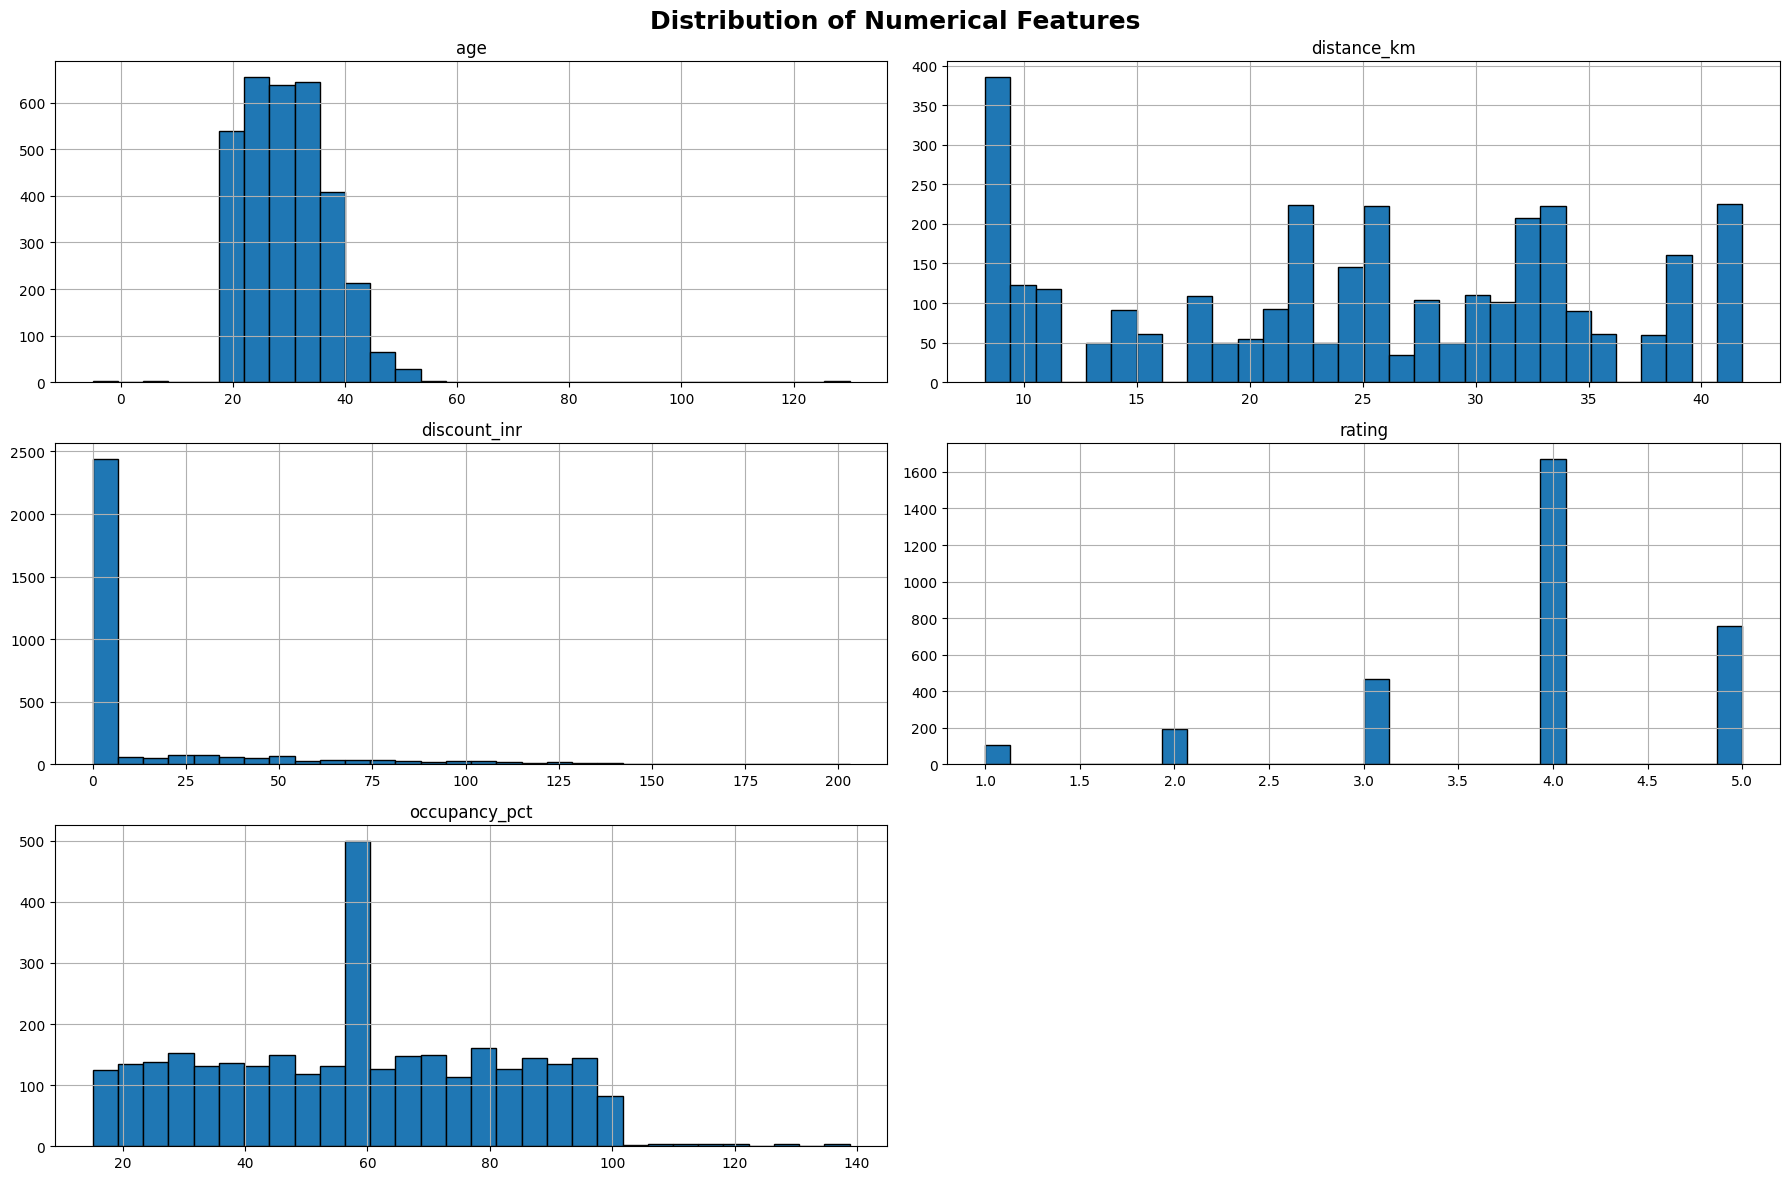

In [121]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(18,12),
    bins=30,
    edgecolor='black'
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 7.1.2 Distribution of Categorical Features

Numerical Columns:
['age', 'distance_km', 'discount_inr', 'rating', 'occupancy_pct']

Categorical Columns:
['trip_id', 'booking_id', 'customer_id', 'customer_name', 'gender', 'city', 'route_id', 'route_name', 'origin_stop', 'destination_stop', 'bus_number', 'bus_type', 'driver_id', 'driver_name', 'trip_date', 'scheduled_departure', 'actual_departure', 'scheduled_arrival', 'actual_arrival', 'fare_inr', 'payment_mode', 'booking_channel', 'seat_number', 'trip_status', 'cancellation_reason', 'weather', 'is_peak_hour', 'subscription_type', 'device_type', 'gps_enabled', 'complaint_raised']


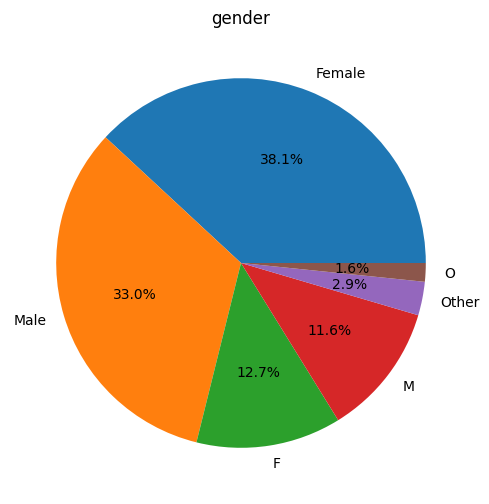

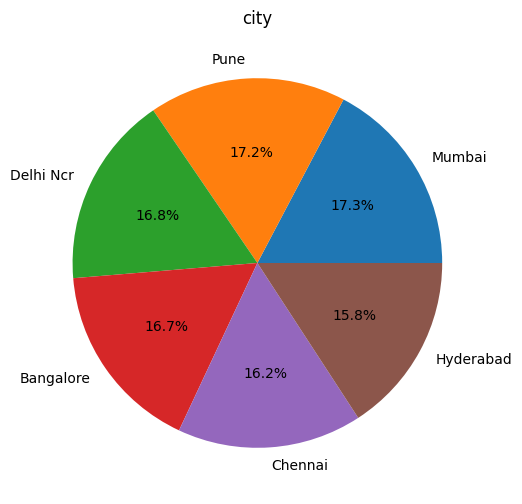

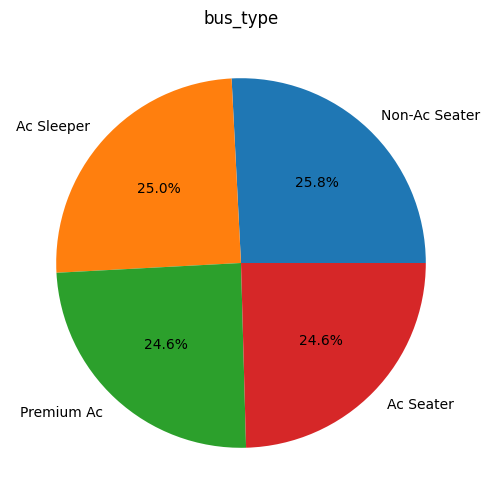

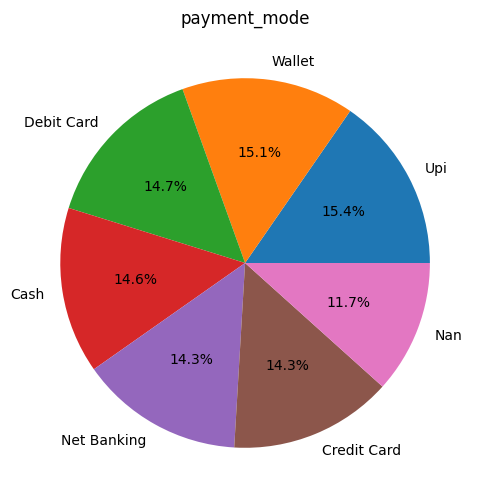

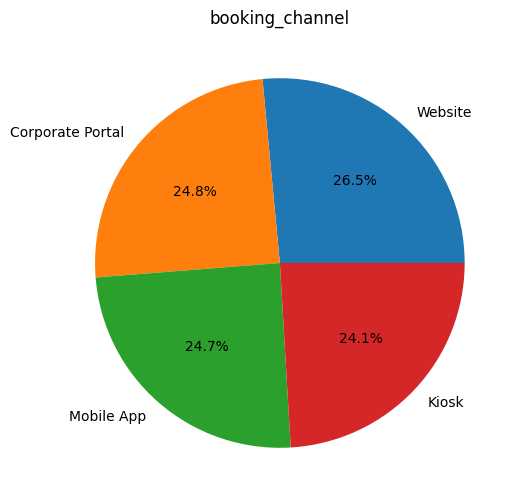

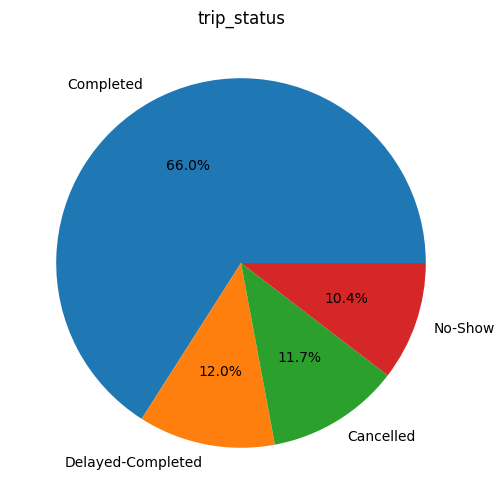

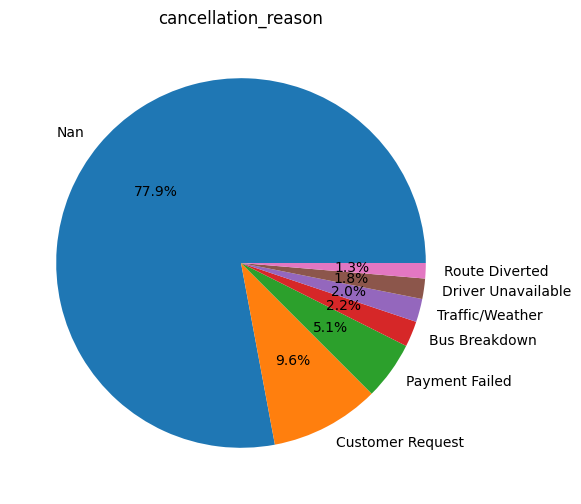

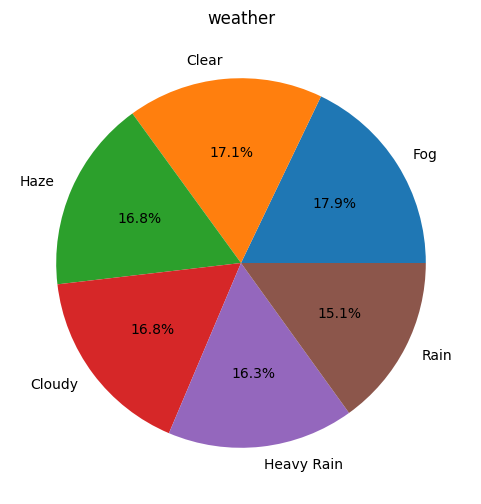

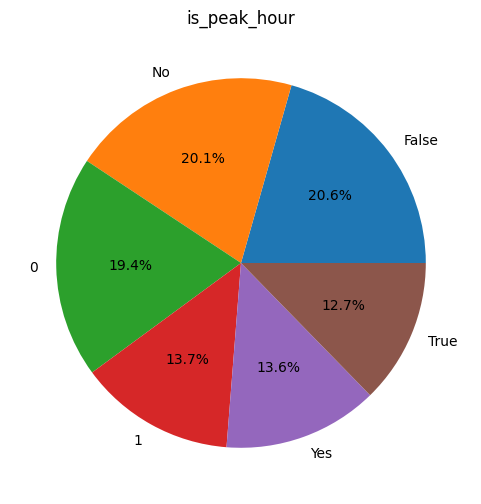

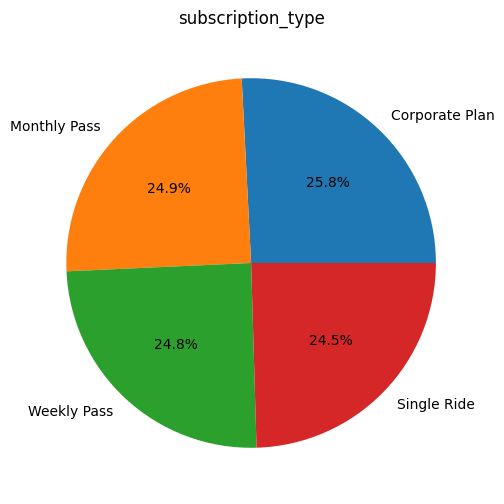

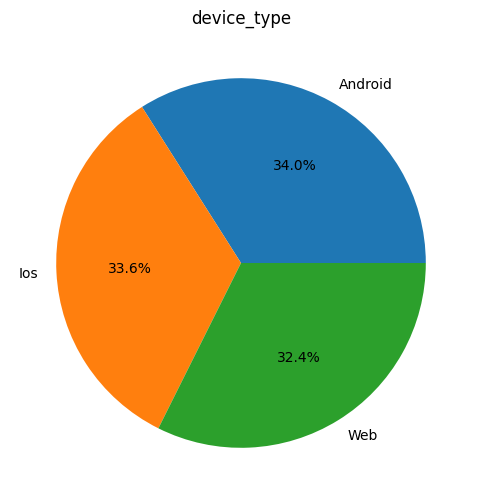

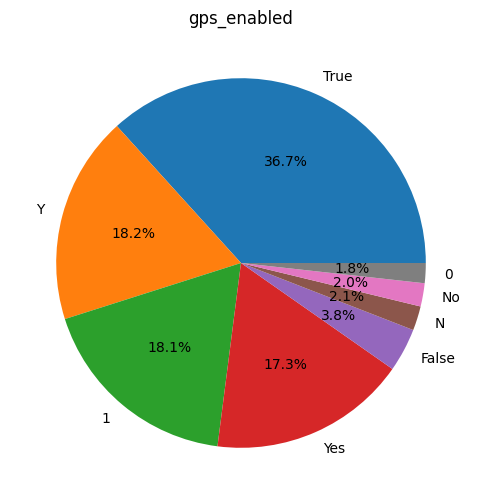

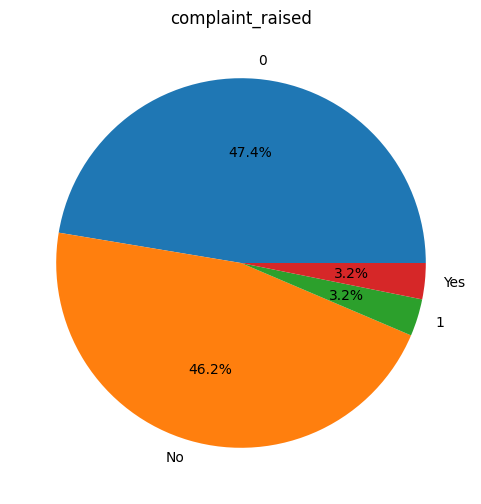

In [122]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:")
print(list(num_cols))

print("\nCategorical Columns:")
print(list(cat_cols))
for col in cat_cols:

    if df[col].nunique()<=8:

        plt.figure(figsize=(6,6))

        df[col].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%"
        )

        plt.ylabel("")

        plt.title(col)

        plt.show()

### 7.1.3 Boxplots of Numerical Features

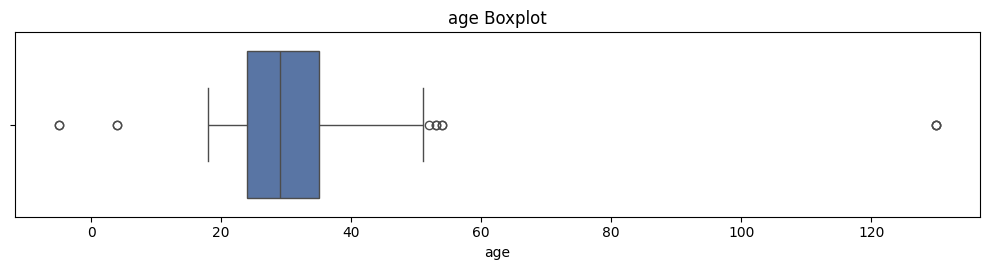

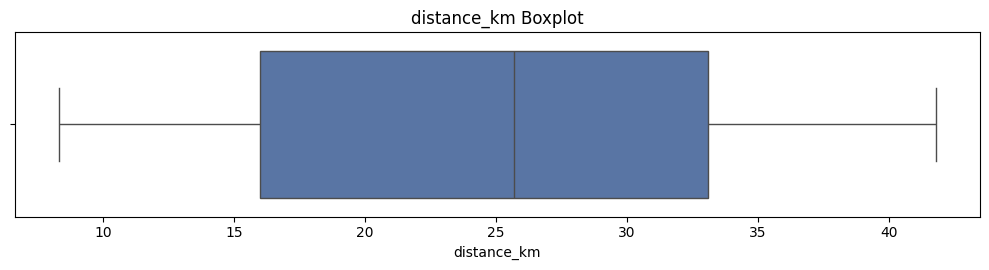

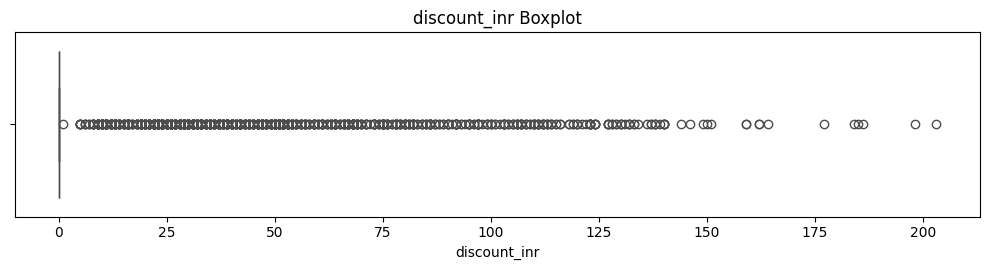

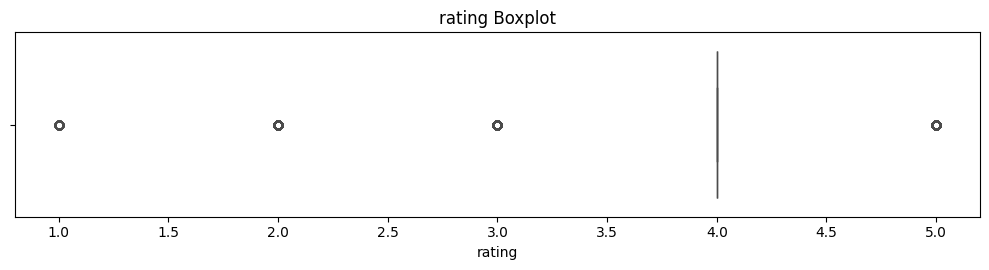

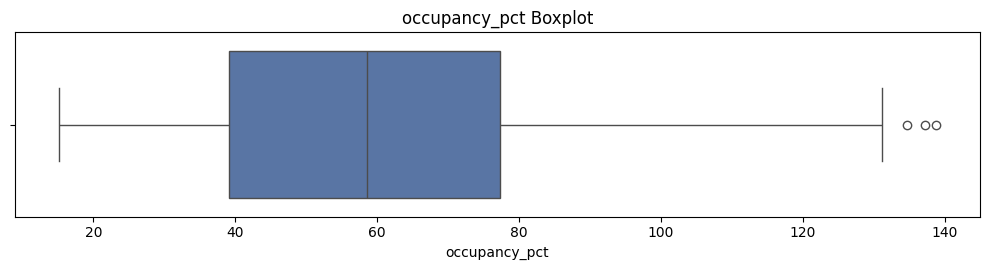

In [123]:
for col in num_cols:

    plt.figure(figsize=(10,2.8))

    sns.boxplot(
        x=df[col],
        color="#4C72B0"
    )

    plt.title(f"{col} Boxplot")

    plt.tight_layout()

    plt.show()

### 7.1.4 Correlation Preview

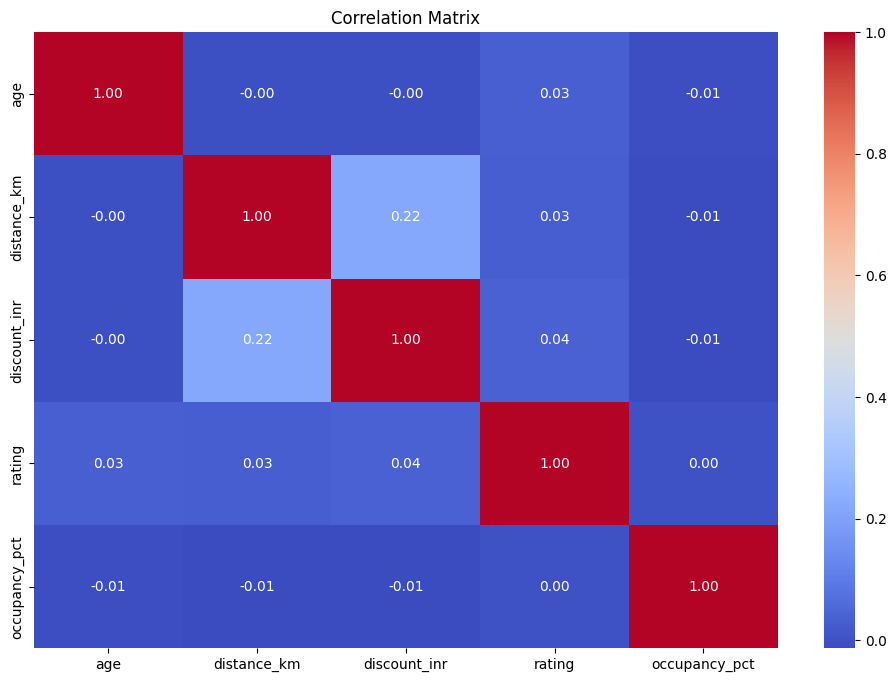

In [124]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### 7.1.5 Descriptive Statistics

In [125]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
age,3200.0,29.502813,8.179144,-5.0,24.000,29.0,35.0,130.0
distance_km,3200.0,24.738375,10.291220,8.3,16.000,25.7,33.1,41.8
discount_inr,3200.0,13.536875,30.350303,0.0,0.000,0.0,0.0,203.0
rating,3200.0,3.866250,0.955194,1.0,4.000,4.0,4.0,5.0
occupancy_pct,3200.0,58.334031,23.576593,15.1,39.175,58.5,77.3,138.8


### 7.1.6 Skewness

In [126]:
skew = pd.DataFrame({
    "Skewness":df[num_cols].skew()
})

display(skew.sort_values("Skewness",ascending=False))

,Skewness
discount_inr,2.603982
age,1.934055
occupancy_pct,0.056347
distance_km,-0.132789
rating,-1.080739


### 7.1.7 Kurtosis

In [127]:
kurt = pd.DataFrame({
    "Kurtosis":df[num_cols].kurt()
})

display(kurt.sort_values("Kurtosis",ascending=False))

,Kurtosis
age,20.515880
discount_inr,6.794017
rating,1.198241
occupancy_pct,-0.802972
distance_km,-1.129204


### 7.1.8 Value Counts of Categorical Features

In [128]:
for col in cat_cols:

    print("="*60)
    print(col.upper())
    print("="*60)

    display(df[col].value_counts())

TRIP_ID


trip_id
Trp000722    1
Trp002088    1
Trp001969    1
Trp002703    1
Trp001487    1
            ..
Trp002802    1
Trp001653    1
Trp003149    1
Trp002453    1
Trp003148    1
Name: count, Length: 3200, dtype: int64

BOOKING_ID


booking_id
Bk82178869    1
Bk66897230    1
Bk90481203    1
Bk73231844    1
Bk49026977    1
             ..
Bk59659578    1
Bk19231279    1
Bk80329799    1
Bk45540207    1
Bk94474114    1
Name: count, Length: 3200, dtype: int64

CUSTOMER_ID


...

device_type
Android    1088
Ios        1076
Web        1036
Name: count, dtype: int64

GPS_ENABLED


gps_enabled
True     1175
Y         582
1         578
Yes       554
False     122
N          68
No         65
0          56
Name: count, dtype: int64

COMPLAINT_RAISED


complaint_raised
0      1516
No     1479
1       104
Yes     101
Name: count, dtype: int64

### 7.1.9 Pie Charts for Low-Cardinality Features

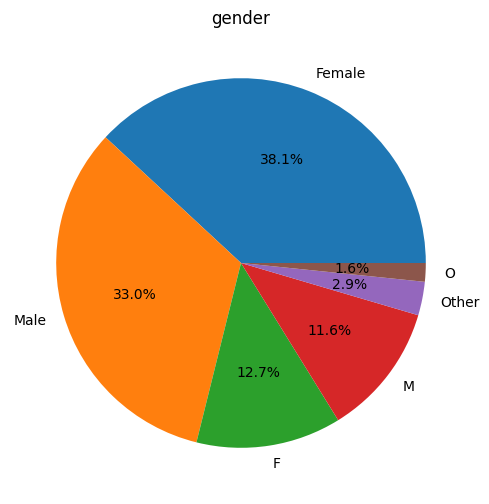

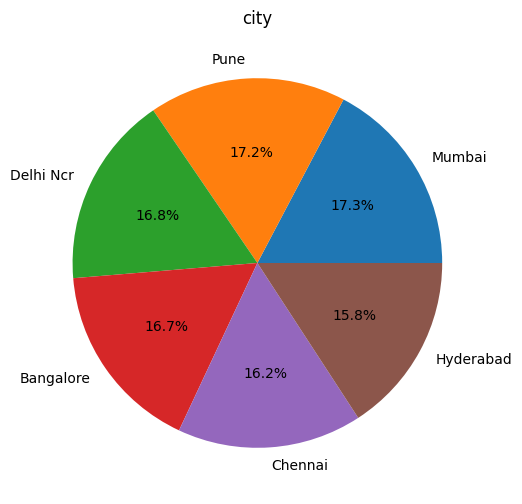

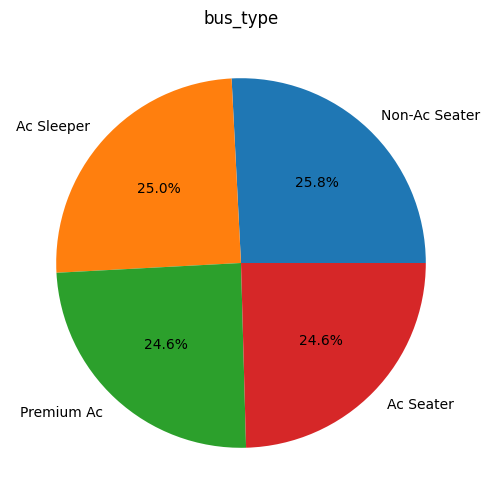

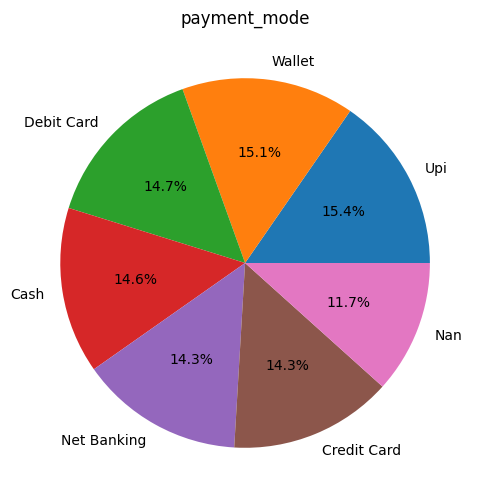

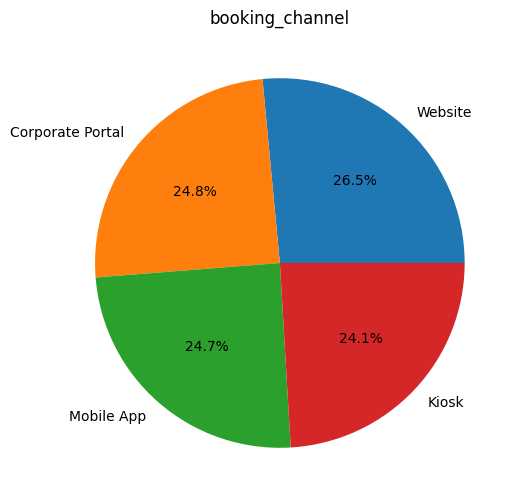

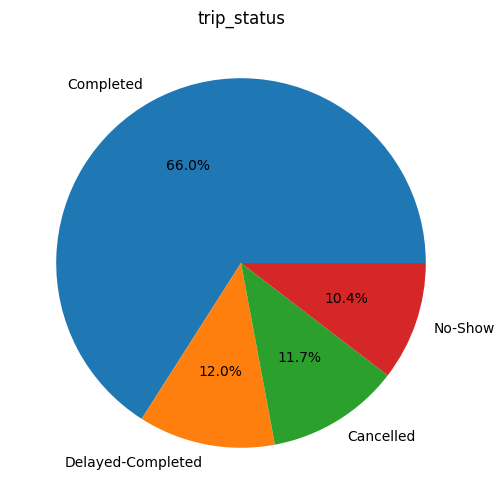

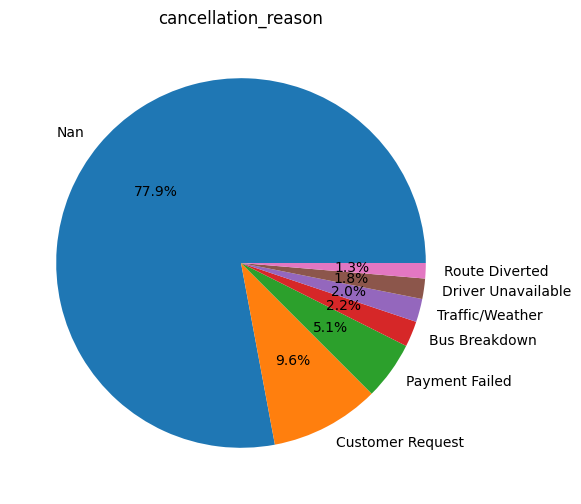

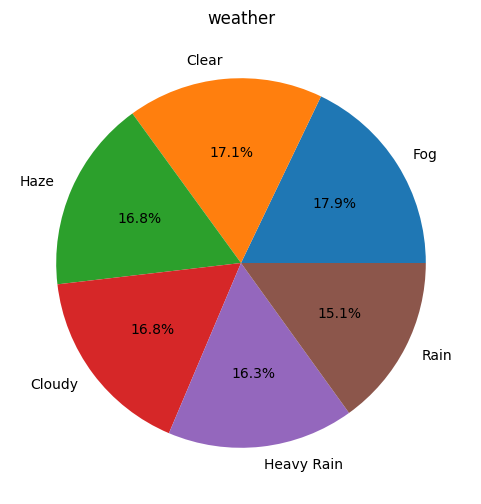

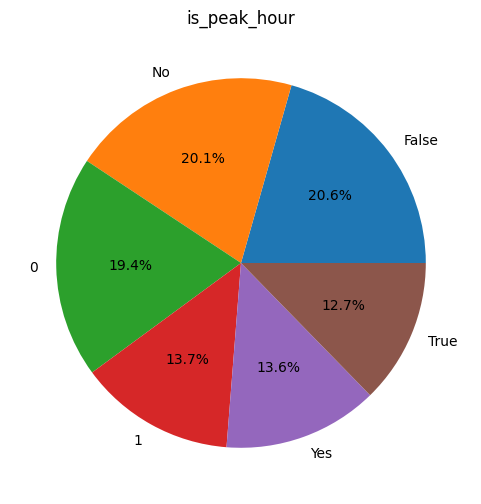

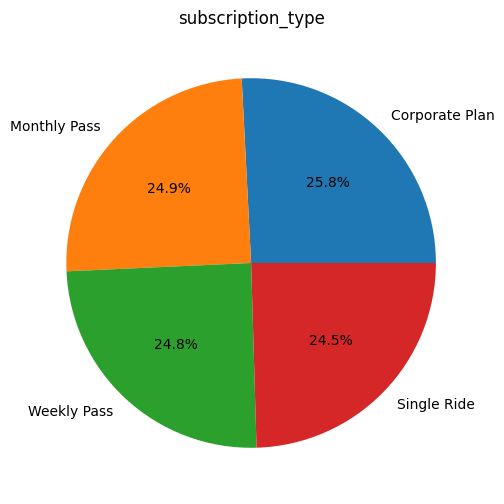

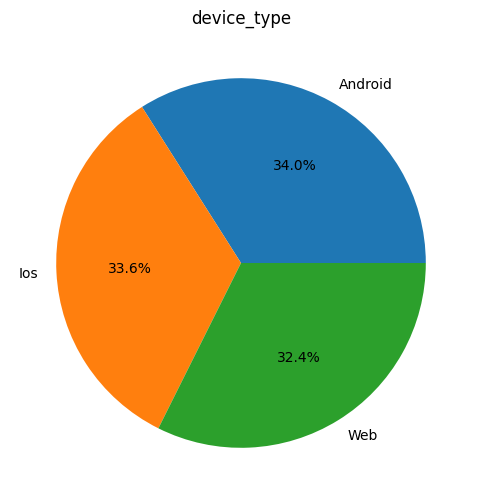

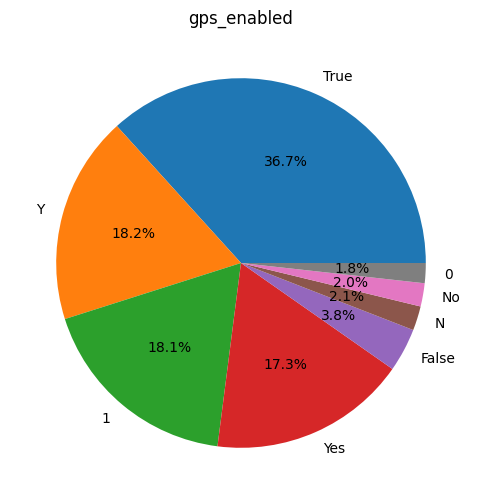

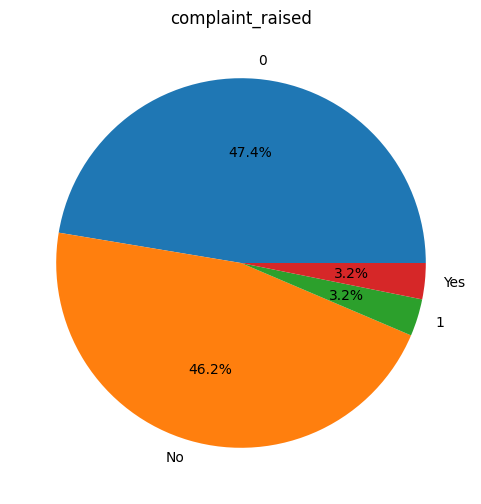

In [129]:
for col in cat_cols:

    if df[col].nunique()<=8:

        plt.figure(figsize=(6,6))

        df[col].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%"
        )

        plt.ylabel("")

        plt.title(col)

        plt.show()

## 7.2 Bivariate Analysis
### 7.2.1 Gender vs Rating

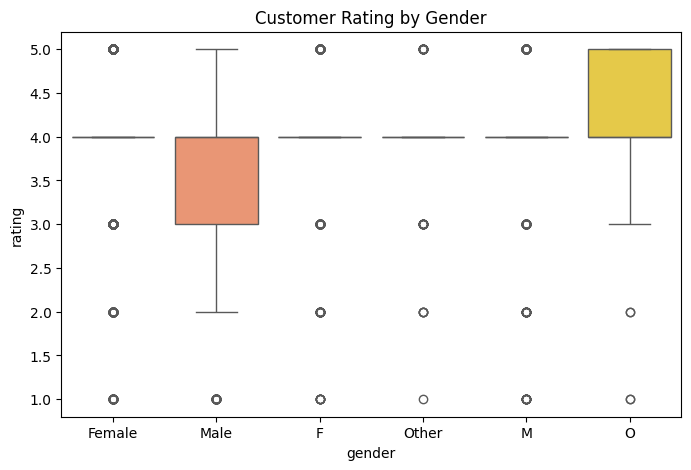

In [130]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="gender",
    y="rating",
    palette="Set2"
)

plt.title("Customer Rating by Gender")
plt.show()

### 7.2.2 Age vs Rating

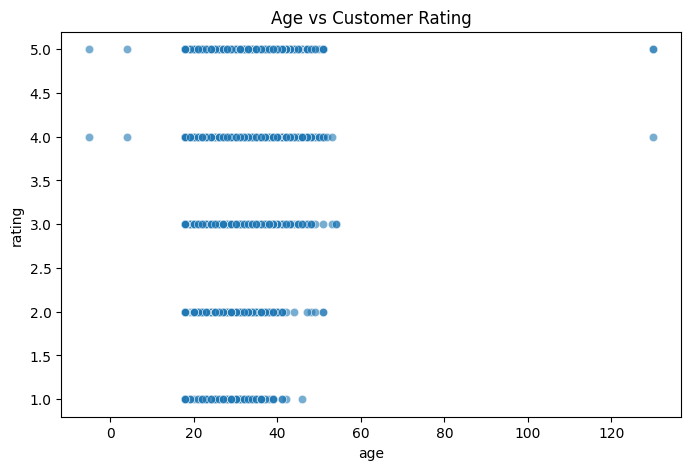

In [131]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="rating",
    alpha=0.6
)

plt.title("Age vs Customer Rating")

plt.show()

### 7.2.3 Fare vs Distance

In [132]:
df["fare_inr"] = (
    df["fare_inr"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("INR", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["fare_inr"] = pd.to_numeric(df["fare_inr"], errors="coerce")

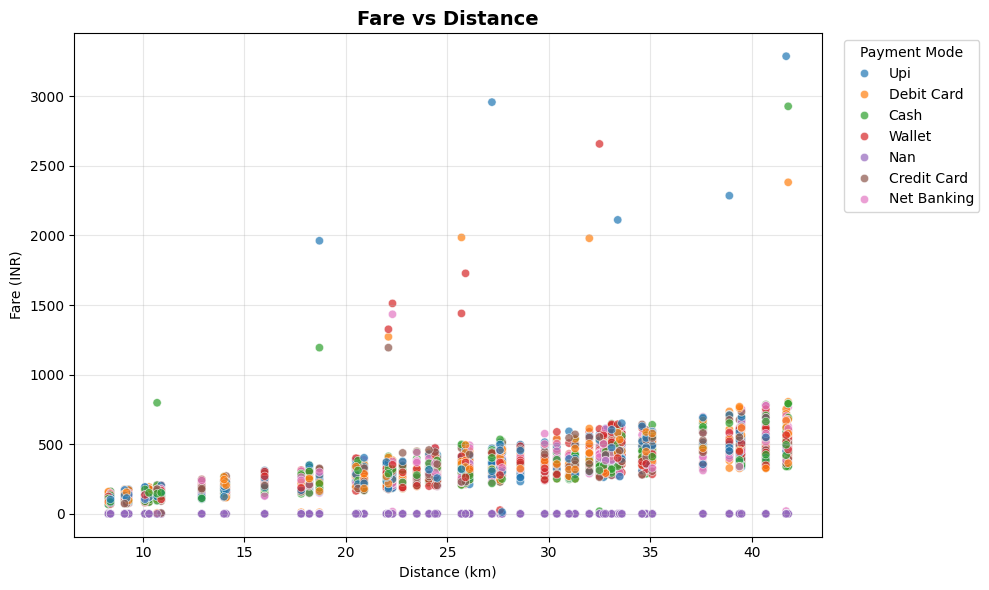

In [133]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="fare_inr",
    hue="payment_mode",
    alpha=0.7
)

plt.title("Fare vs Distance", fontsize=14, fontweight="bold")
plt.xlabel("Distance (km)")
plt.ylabel("Fare (INR)")
plt.legend(title="Payment Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2.4 City-wise Revenue

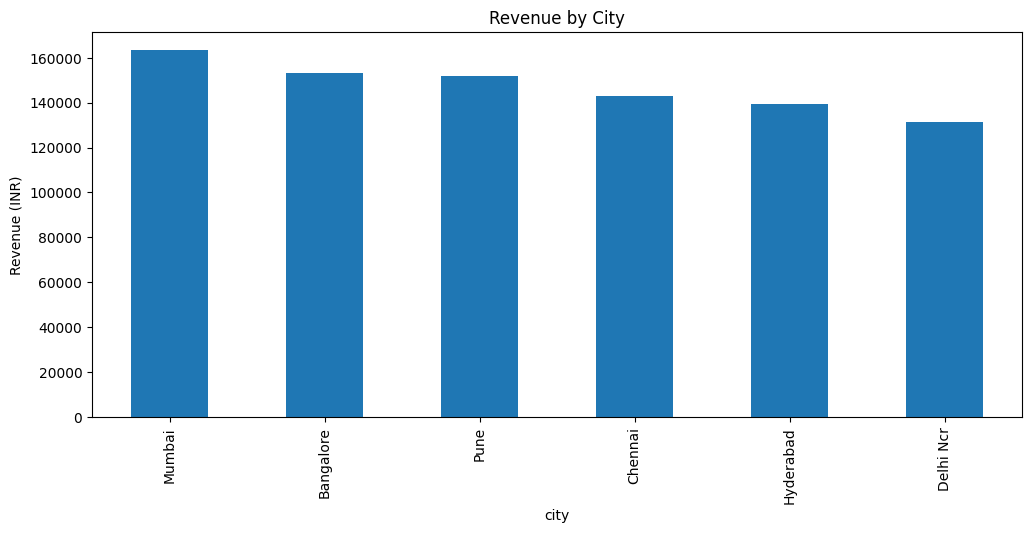

In [134]:
city_rev = (
    df.groupby("city")["fare_inr"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

city_rev.plot(kind="bar")

plt.ylabel("Revenue (INR)")
plt.title("Revenue by City")

plt.show()

### 7.2.5 Booking Channel Revenue


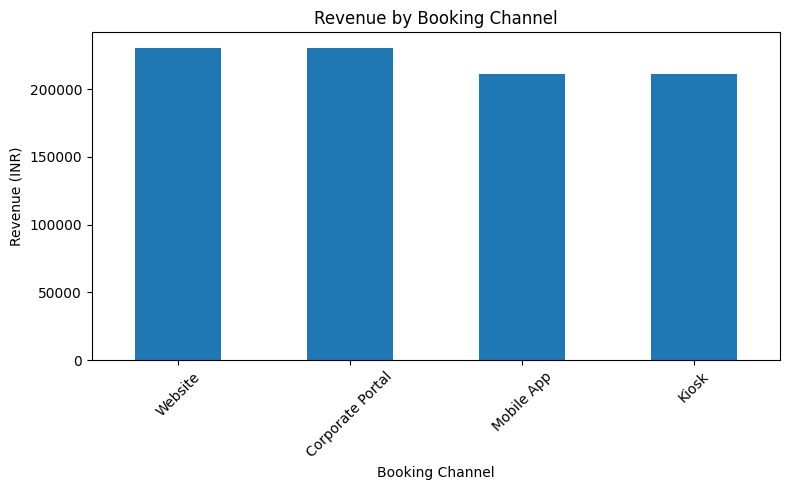

In [135]:
channel = (
    df.groupby("booking_channel")["fare_inr"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
channel.plot(kind="bar")
plt.title("Revenue by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.2.6 Payment Mode Revenue


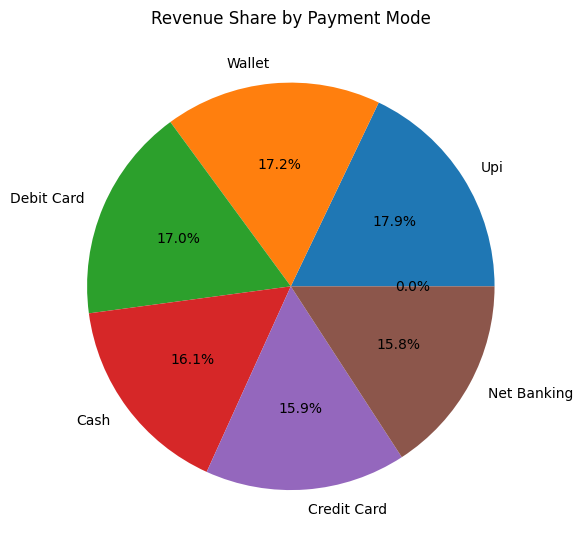

In [136]:
payment = (
    df.groupby("payment_mode")["fare_inr"]
      .sum()
      .sort_values(ascending=False)
)

payment.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

plt.ylabel("")
plt.title("Revenue Share by Payment Mode")
plt.tight_layout()
plt.show()


### 7.2.7 Route-wise Revenue


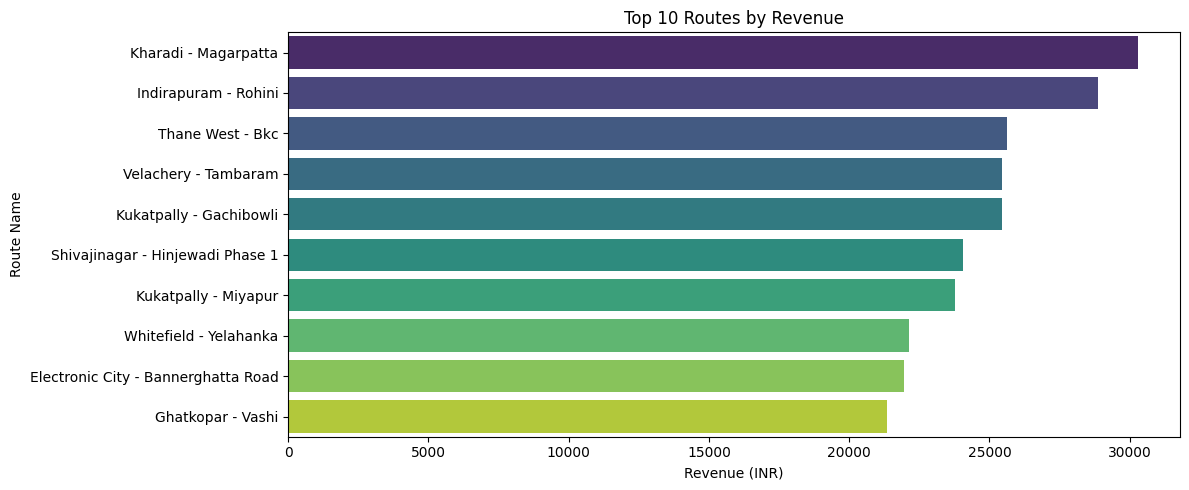

In [137]:
route = (
    df.groupby("route_name")["fare_inr"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=route.values,
    y=route.index,
    palette="viridis"
)

plt.title("Top 10 Routes by Revenue")
plt.xlabel("Revenue (INR)")
plt.ylabel("Route Name")
plt.tight_layout()
plt.show()


### 7.2.8 Occupancy vs Rating


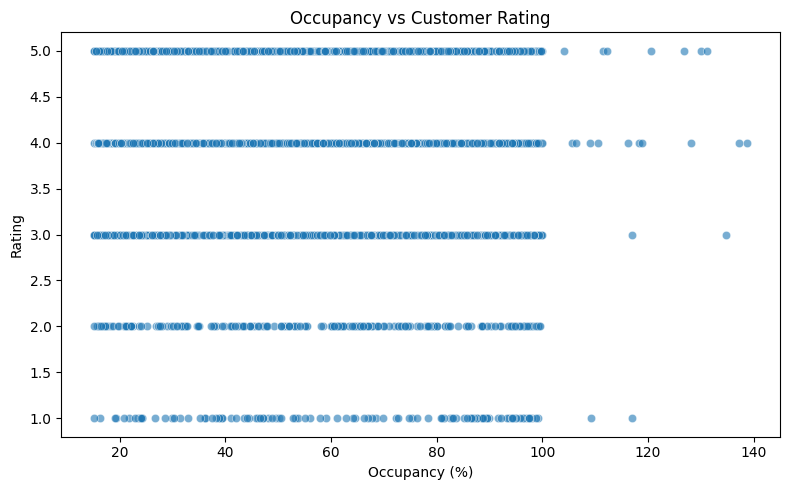

In [138]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="occupancy_pct",
    y="rating",
    alpha=0.6
)

plt.title("Occupancy vs Customer Rating")
plt.xlabel("Occupancy (%)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()


### 7.2.9 Weather vs Trip Status


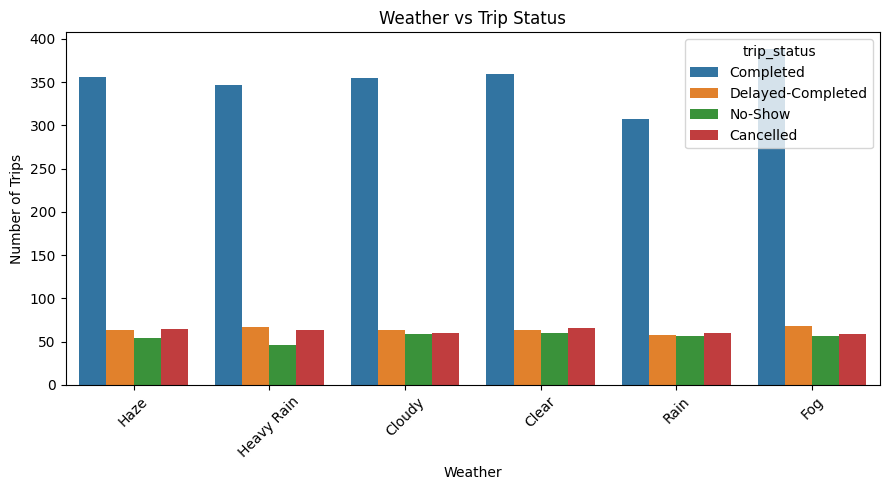

In [139]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="weather",
    hue="trip_status"
)

plt.title("Weather vs Trip Status")
plt.xlabel("Weather")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.2.10 Subscription Type vs Revenue


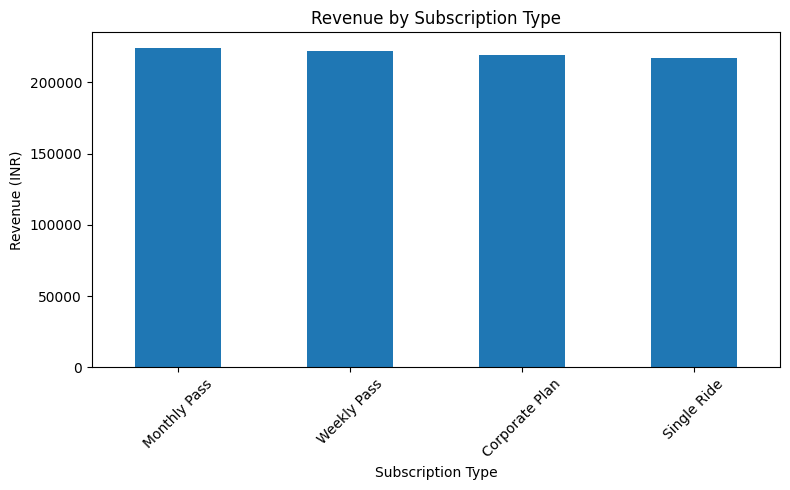

In [140]:
sub = (
    df.groupby("subscription_type")["fare_inr"]
      .sum()
      .sort_values(ascending=False)
)

sub.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Revenue by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7.3 Multivariate Analysis
### 7.3.1 Correlation Heatmap


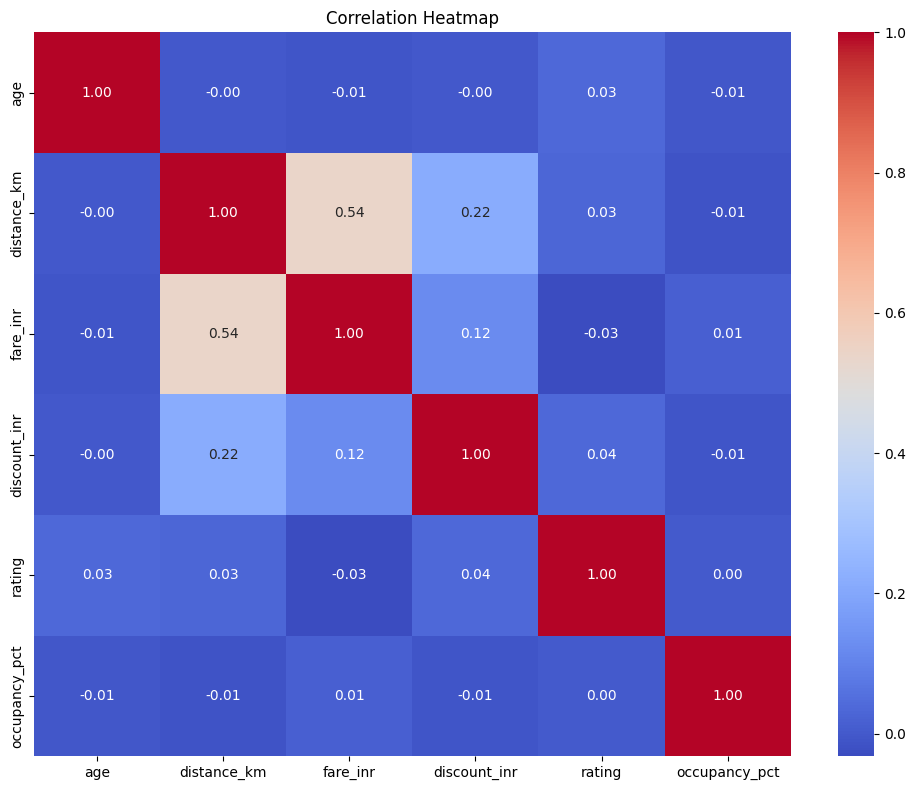

In [141]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes("number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


### 7.3.2 Pair Plot


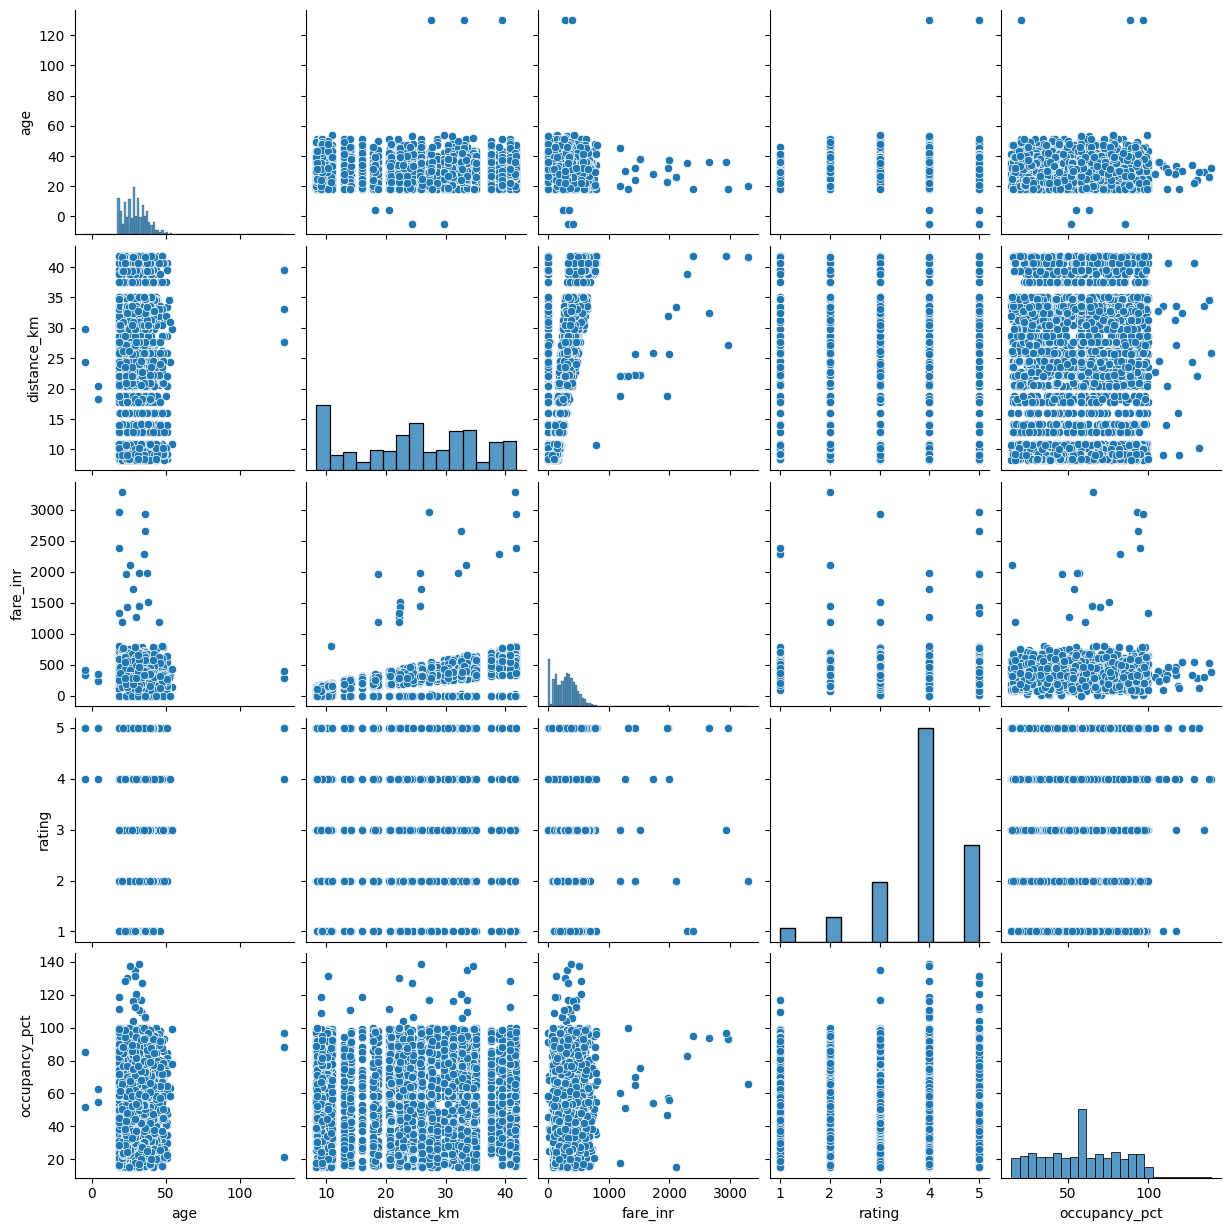

In [142]:
sns.pairplot(
    df[
        [
            "age",
            "distance_km",
            "fare_inr",
            "rating",
            "occupancy_pct"
        ]
    ]
)

plt.show()


### 7.3.3 Revenue by City and Payment Mode


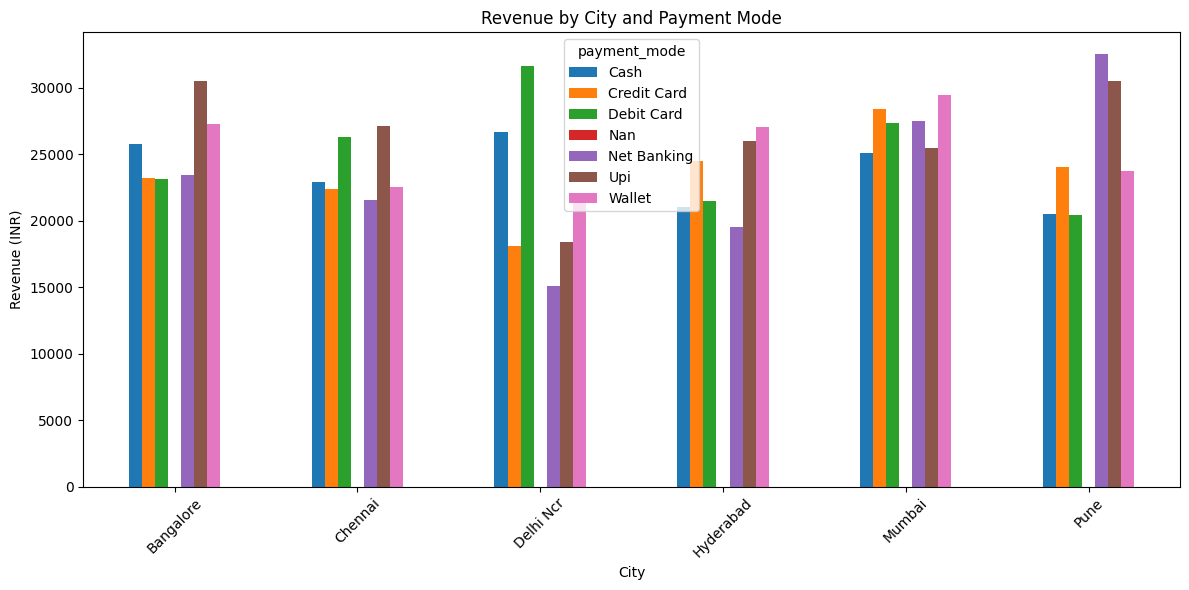

In [143]:
pivot = pd.pivot_table(
    df,
    values="fare_inr",
    index="city",
    columns="payment_mode",
    aggfunc="sum",
    fill_value=0
)

pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Revenue by City and Payment Mode")
plt.xlabel("City")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.3.4 Average Rating by City


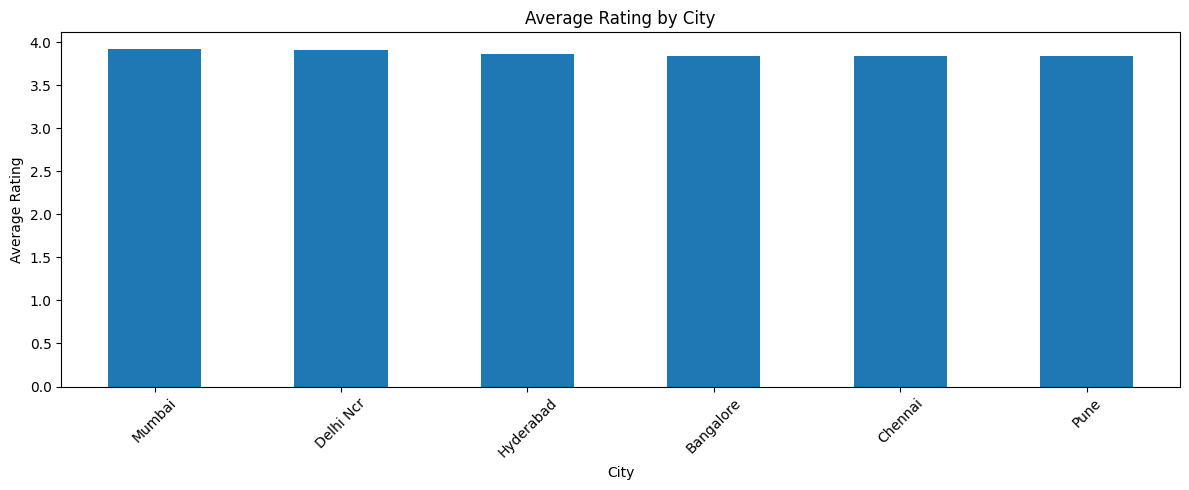

In [144]:
rating = (
    df.groupby("city")["rating"]
      .mean()
      .sort_values(ascending=False)
)

rating.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Rating by City")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.3.5 Occupancy by Bus Type


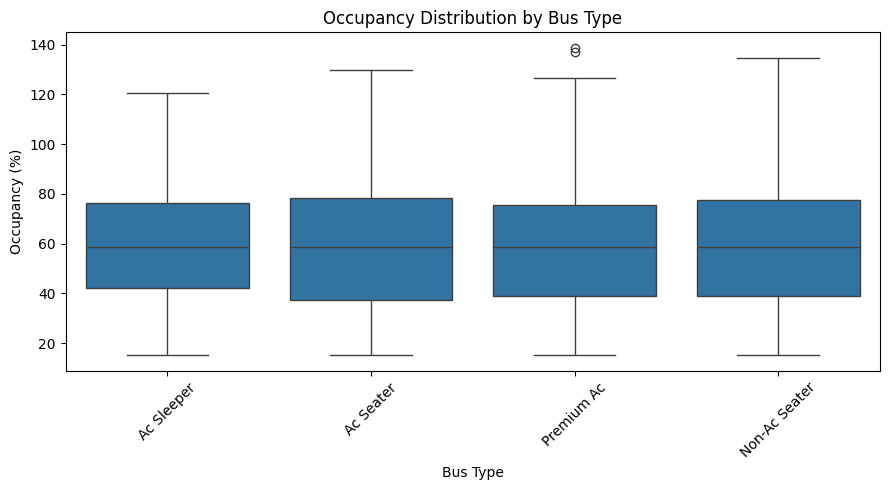

In [145]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="bus_type",
    y="occupancy_pct"
)

plt.title("Occupancy Distribution by Bus Type")
plt.xlabel("Bus Type")
plt.ylabel("Occupancy (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 7.3.6 Revenue Heatmap


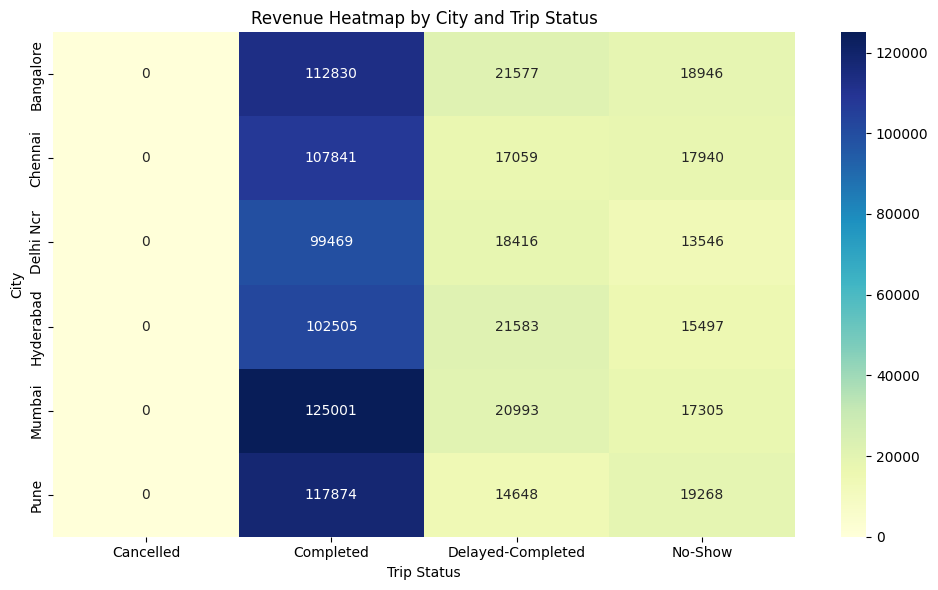

In [146]:
heat = pd.pivot_table(
    df,
    values="fare_inr",
    index="city",
    columns="trip_status",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    heat,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Revenue Heatmap by City and Trip Status")
plt.xlabel("Trip Status")
plt.ylabel("City")
plt.tight_layout()
plt.show()


## 8. Business Insights (KPIs)

This section converts the cleaned operational dataset into business-facing KPIs. The goal is to summarize revenue strength, demand concentration, service reliability, customer experience, and channel/payment behavior in a format that can support management decisions.


In [147]:
numeric_columns = ["fare_inr", "rating", "distance_km", "occupancy_pct", "is_peak_hour"]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column].astype(str).str.replace(r"[^0-9.\-]", "", regex=True),
            errors="coerce"
        )

total_trips = len(df)
total_revenue = df["fare_inr"].sum()
avg_fare = df["fare_inr"].mean()
avg_rating = df["rating"].mean()
avg_distance = df["distance_km"].mean()
avg_occupancy = df["occupancy_pct"].mean()
completion_rate = df["trip_status"].eq("Completed").mean() * 100
cancellation_rate = df["trip_status"].str.contains("cancel", case=False, na=False).mean() * 100
complaint_rate = df["complaint_raised"].eq("Yes").mean() * 100
peak_hour_share = df["is_peak_hour"].eq(1).mean() * 100
digital_payment_share = df["payment_mode"].isin(["UPI", "Upi", "Card", "Wallet", "Net Banking"]).mean() * 100

kpi_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Trips",
            "Total Revenue (INR)",
            "Average Fare (INR)",
            "Average Rating",
            "Average Distance (km)",
            "Average Occupancy (%)",
            "Trip Completion Rate (%)",
            "Cancellation Rate (%)",
            "Complaint Rate (%)",
            "Peak-Hour Trip Share (%)",
            "Digital Payment Share (%)"
        ],
        "Value": [
            total_trips,
            total_revenue,
            avg_fare,
            avg_rating,
            avg_distance,
            avg_occupancy,
            completion_rate,
            cancellation_rate,
            complaint_rate,
            peak_hour_share,
            digital_payment_share
        ]
    }
)

display(kpi_summary.style.format({"Value": "{:,.2f}"}))

print("Top City by Bookings")
display(df["city"].value_counts().head(10).to_frame("bookings"))

print("Top Route by Bookings")
display(df["route_name"].value_counts().head(10).to_frame("bookings"))

print("Revenue by Payment Mode")
display(df.groupby("payment_mode")["fare_inr"].agg(trips="count", revenue="sum", avg_fare="mean").sort_values("revenue", ascending=False))

print("Trip Status Mix")
display(df["trip_status"].value_counts(normalize=True).mul(100).round(2).to_frame("share_pct"))


,Metric,Value
0,Total Trips,"3,200.00"
1,Total Revenue (INR),"882,298.00"
2,Average Fare (INR),287.58
3,Average Rating,3.87
4,Average Distance (km),24.74
5,Average Occupancy (%),58.33
6,Trip Completion Rate (%),65.97
7,Cancellation Rate (%),11.66
8,Complaint Rate (%),3.16
9,Peak-Hour Trip Share (%),13.66


Top City by Bookings


,bookings
city,
Mumbai,553
Pune,552
Delhi Ncr,537
Bangalore,535
Chennai,517
Hyderabad,506


Top Route by Bookings


,bookings
route_name,
Tambaram - Adyar,69
Rohini - Indirapuram,68
Saket - Faridabad,67
Lower Parel - Mulund,64
Thane West - Borivali,63
Kharadi - Magarpatta,62
Whitefield - Yelahanka,61
Hebbal - Electronic City,61
Kukatpally - Uppal,61


Revenue by Payment Mode


,trips,revenue,avg_fare
payment_mode,,,
Upi,471,157928.0,335.303609
Wallet,462,151488.0,327.896104
Debit Card,450,150423.0,334.273333
Cash,448,142109.0,317.207589
Credit Card,440,140677.0,319.720455
Net Banking,437,139673.0,319.617849
Nan,360,0.0,0.000000


Trip Status Mix


,share_pct
trip_status,
Completed,65.97
Delayed-Completed,11.97
Cancelled,11.66
No-Show,10.41


### 8.1 City and Route Performance Summary


In [148]:
city_summary = (
    df.groupby("city")
      .agg(
          total_trips=("fare_inr", "count"),
          total_revenue=("fare_inr", "sum"),
          avg_fare=("fare_inr", "mean"),
          avg_rating=("rating", "mean"),
          avg_occupancy=("occupancy_pct", "mean"),
          completion_rate=("trip_status", lambda x: x.eq("Completed").mean() * 100),
          complaint_rate=("complaint_raised", lambda x: x.eq("Yes").mean() * 100)
      )
      .sort_values("total_revenue", ascending=False)
)

display(city_summary)

route_summary = (
    df.groupby("route_name")
      .agg(
          total_trips=("fare_inr", "count"),
          total_revenue=("fare_inr", "sum"),
          avg_rating=("rating", "mean"),
          avg_occupancy=("occupancy_pct", "mean"),
          completion_rate=("trip_status", lambda x: x.eq("Completed").mean() * 100),
          complaint_rate=("complaint_raised", lambda x: x.eq("Yes").mean() * 100)
      )
      .sort_values("total_revenue", ascending=False)
      .head(10)
)

display(route_summary)

bus_type_summary = (
    df.groupby("bus_type")
      .agg(
          total_trips=("fare_inr", "count"),
          total_revenue=("fare_inr", "sum"),
          avg_fare=("fare_inr", "mean"),
          avg_rating=("rating", "mean"),
          avg_occupancy=("occupancy_pct", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

display(bus_type_summary)


,total_trips,total_revenue,avg_fare,avg_rating,avg_occupancy,completion_rate,complaint_rate
city,,,,,,,
Mumbai,531,163299.0,307.531073,3.916817,57.794756,68.354430,3.254973
Bangalore,518,153353.0,296.048263,3.842991,58.151028,65.607477,3.177570
Pune,523,151790.0,290.229446,3.833333,59.200181,66.847826,3.079710
Chennai,497,142840.0,287.404427,3.841393,57.890716,65.570600,2.707930
Hyderabad,484,139585.0,288.398760,3.855731,57.743676,65.217391,3.557312
Delhi Ncr,515,131431.0,255.205825,3.905028,59.164432,64.059590,3.165736


,total_trips,total_revenue,avg_rating,avg_occupancy,completion_rate,complaint_rate
route_name,,,,,,
Kharadi - Magarpatta,59,30277.0,3.870968,60.724194,75.806452,6.451613
Indirapuram - Rohini,50,28878.0,3.925926,55.725926,70.370370,1.851852
Thane West - Bkc,53,25607.0,3.816667,52.876667,61.666667,5.000000
Velachery - Tambaram,58,25444.0,3.783333,59.195000,58.333333,1.666667
Kukatpally - Gachibowli,52,25439.0,3.870370,55.601852,66.666667,0.000000
Shivajinagar - Hinjewadi Phase 1,51,24063.0,3.833333,59.024074,75.925926,1.851852
Kukatpally - Miyapur,58,23778.0,4.033898,58.140678,62.711864,3.389831
Whitefield - Yelahanka,56,22121.0,3.688525,59.290164,57.377049,1.639344
Electronic City - Bannerghatta Road,52,21945.0,4.056604,57.033962,69.811321,1.886792


,total_trips,total_revenue,avg_fare,avg_rating,avg_occupancy
bus_type,,,,,
Premium Ac,760,257346.0,338.613158,3.848793,57.299746
Ac Sleeper,768,237150.0,308.789062,3.875156,59.222222
Non-Ac Seater,792,199425.0,251.799242,3.835351,58.501937
Ac Seater,748,188377.0,251.840909,3.907125,58.288041


## 9. Executive Dashboard (Plotly)


In [151]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=(
        "Bookings by City",
        "Revenue by Payment Mode",
        "Trip Status Mix",
        "Customer Ratings",
        "Revenue by Bus Type",
        "Average Occupancy by City"
    ),
    specs=[
        [{"type": "bar"}, {"type": "pie"}],
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "bar"}]
    ],
    vertical_spacing=0.12
)

city = df["city"].value_counts().sort_values(ascending=False)

fig.add_trace(
    go.Bar(
        x=city.index,
        y=city.values,
        name="Bookings",
        marker_color="#2563eb"
    ),
    row=1,
    col=1
)

payment = df.groupby("payment_mode")["fare_inr"].sum().sort_values(ascending=False)

fig.add_trace(
    go.Pie(
        labels=payment.index,
        values=payment.values,
        name="Payment Mode",
        hole=0.35
    ),
    row=1,
    col=2
)

status = df["trip_status"].value_counts().sort_values(ascending=False)

fig.add_trace(
    go.Bar(
        x=status.index,
        y=status.values,
        name="Trip Status",
        marker_color="#16a34a"
    ),
    row=2,
    col=1
)

rating = df["rating"].value_counts().sort_index()

fig.add_trace(
    go.Bar(
        x=rating.index,
        y=rating.values,
        name="Ratings",
        marker_color="#f59e0b"
    ),
    row=2,
    col=2
)

bus_revenue = df.groupby("bus_type")["fare_inr"].sum().sort_values(ascending=False)

fig.add_trace(
    go.Bar(
        x=bus_revenue.index,
        y=bus_revenue.values,
        name="Bus Type Revenue",
        marker_color="#7c3aed"
    ),
    row=3,
    col=1
)

city_occupancy = df.groupby("city")["occupancy_pct"].mean().sort_values(ascending=False)

fig.add_trace(
    go.Bar(
        x=city_occupancy.index,
        y=city_occupancy.values,
        name="Average Occupancy",
        marker_color="#0891b2"
    ),
    row=3,
    col=2
)

fig.update_yaxes(title_text="Bookings", row=1, col=1)
fig.update_yaxes(title_text="Trips", row=2, col=1)
fig.update_yaxes(title_text="Customers", row=2, col=2)
fig.update_yaxes(title_text="Revenue (INR)", row=3, col=1)
fig.update_yaxes(title_text="Occupancy (%)", row=3, col=2)

fig.update_layout(
    height=1050,
    title_text="CityFlo Executive Dashboard",
    showlegend=False,
    template="plotly_white",
    margin=dict(t=90, l=50, r=40, b=60)
)

fig.show()


## 10. Key Findings


In [152]:
top_city = df["city"].value_counts().idxmax()
top_city_share = df["city"].value_counts(normalize=True).max() * 100
top_route = df["route_name"].value_counts().idxmax()
top_route_share = df["route_name"].value_counts(normalize=True).max() * 100
top_payment_mode = df["payment_mode"].value_counts().idxmax()
top_booking_channel = df["booking_channel"].value_counts().idxmax()
highest_revenue_city = df.groupby("city")["fare_inr"].sum().idxmax()
highest_revenue_route = df.groupby("route_name")["fare_inr"].sum().idxmax()
highest_rating_city = df.groupby("city")["rating"].mean().idxmax()
lowest_rating_city = df.groupby("city")["rating"].mean().idxmin()
highest_occupancy_city = df.groupby("city")["occupancy_pct"].mean().idxmax()
lowest_occupancy_city = df.groupby("city")["occupancy_pct"].mean().idxmin()
best_bus_type = df.groupby("bus_type")["fare_inr"].sum().idxmax()
completion_rate = df["trip_status"].eq("Completed").mean() * 100
complaint_rate = df["complaint_raised"].eq("Yes").mean() * 100
avg_occupancy = df["occupancy_pct"].mean()
avg_rating = df["rating"].mean()

print("Key Findings")
print("-" * 80)
print(f"1. Demand is strongest in {top_city}, which contributes {top_city_share:.2f}% of total bookings.")
print(f"2. The most frequently used route is {top_route}, accounting for {top_route_share:.2f}% of all trips.")
print(f"3. {highest_revenue_city} generates the highest city-level revenue, while {highest_revenue_route} is the top revenue route.")
print(f"4. {top_payment_mode} is the most preferred payment mode, showing where payment convenience is currently strongest.")
print(f"5. {top_booking_channel} is the leading booking channel and should be treated as a priority customer touchpoint.")
print(f"6. The overall trip completion rate is {completion_rate:.2f}%, which is the main reliability KPI to track over time.")
print(f"7. Average occupancy is {avg_occupancy:.2f}%; {highest_occupancy_city} has the strongest occupancy and {lowest_occupancy_city} has the weakest.")
print(f"8. Average customer rating is {avg_rating:.2f}; {highest_rating_city} performs best on satisfaction and {lowest_rating_city} needs service attention.")
print(f"9. Complaint rate is {complaint_rate:.2f}%, so complaints should be monitored by route, driver, bus type, and weather condition.")
print(f"10. {best_bus_type} contributes the highest revenue among bus types and can guide fleet allocation decisions.")


Key Findings
--------------------------------------------------------------------------------
1. Demand is strongest in Mumbai, which contributes 17.28% of total bookings.
2. The most frequently used route is Tambaram - Adyar, accounting for 2.16% of all trips.
3. Mumbai generates the highest city-level revenue, while Kharadi - Magarpatta is the top revenue route.
4. Upi is the most preferred payment mode, showing where payment convenience is currently strongest.
5. Website is the leading booking channel and should be treated as a priority customer touchpoint.
6. The overall trip completion rate is 65.97%, which is the main reliability KPI to track over time.
7. Average occupancy is 58.33%; Pune has the strongest occupancy and Hyderabad has the weakest.
8. Average customer rating is 3.87; Mumbai performs best on satisfaction and Pune needs service attention.
9. Complaint rate is 3.16%, so complaints should be monitored by route, driver, bus type, and weather condition.
10. Premium Ac c

## 11. Recommendations

1. Focus marketing and service expansion on high-revenue cities and routes.
2. Improve low-rated routes by reviewing delays, occupancy, and customer feedback.
3. Promote the strongest booking channel while improving weaker channels.
4. Track cancellation and failure patterns across weather and trip status.
5. Use occupancy trends to optimize bus allocation during peak and low-demand periods.
6. Encourage digital payment modes if they contribute strong revenue and convenience.


## 12. Conclusion

This exploratory data analysis converted the CityFlo Bus Service dataset into a structured view of demand, revenue, customer behavior, operational performance, and satisfaction. After cleaning and standardizing the data, the analysis showed how bookings and revenue vary across cities, routes, bus types, payment modes, booking channels, trip status, and customer ratings.

The business insights indicate that CityFlo should manage performance at both the city and route level. High-demand and high-revenue routes can be prioritized for frequency improvements, fleet allocation, subscription offers, and corporate partnerships. Routes or cities with weaker ratings, lower occupancy, higher complaints, or lower completion rates should be reviewed for schedule reliability, driver performance, bus quality, stop coverage, weather disruption, and customer support issues.

The executive dashboard provides a compact management view of the most important KPIs: bookings by city, revenue by payment mode, trip status mix, customer rating distribution, revenue by bus type, and occupancy by city. Together, these metrics help identify where CityFlo is performing well, where operational leakage may exist, and where growth investments are most likely to produce returns.

Overall, the cleaned dataset is suitable for further business intelligence, forecasting, route optimization, churn analysis, and predictive modeling. With regular monitoring of completion rate, occupancy, complaints, revenue per route, and customer satisfaction, CityFlo can make more data-driven decisions to improve service reliability, strengthen customer experience, and scale its metro city operations more efficiently.
